In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
import random
import os
import tensorflow as tf

# 设置随机种子以确保结果可复现
SEED = 120
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# 配置TensorFlow确定性操作
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ 所有库导入完成")
print(f"✓ 随机种子已设置为: {SEED}")

✓ 所有库导入完成
✓ 随机种子已设置为: 120


## 第一步：数据加载与时间戳解析

In [2]:
# 读取数据
try:
    df = pd.read_excel('CO2_capacity.xlsx', engine='openpyxl')
    print(f"✓ 成功读取数据，形状：{df.shape}")
except Exception as e:
    raise RuntimeError(f"读取失败：{e}")

# 显示前几行
print(f"\n数据前 5 行：")
print(df.head())

# 确定列
time_col = df.columns[0]  # 第一列是时间戳
target_col = df.columns[-1]  # 最后一列是目标（CO2 容量）

print(f"\n列角色定义：")
print(f"  • 时间列：{time_col}")
print(f"  • 目标列：{target_col}")
print(f"  • 数据频率：1 分钟")
print(f"  • 总记录数：{len(df)}")

✓ 成功读取数据，形状：(7200, 59)

数据前 5 行：
                 Date      PI-2       TI-2         FI-2      PI-3       TI-3  \
0 2020-01-20 00:00:00 -0.053126  34.736652  1543.938721  0.052434  45.023132   
1 2020-01-20 00:01:00 -0.053289  34.732132  1541.767578  0.052564  45.045799   
2 2020-01-20 00:02:00 -0.053386  34.761639  1545.614746  0.052390  45.088932   
3 2020-01-20 00:03:00 -0.053370  34.731682  1544.225952  0.052236  45.071358   
4 2020-01-20 00:04:00 -0.053144  34.718353  1540.848267  0.052370  45.036755   

       O2-3      TI-32      TI-33      TI-34  ...        FI-16      TI-16  \
0  5.170577  37.777477  50.215652  61.217957  ...  9634.049805  34.619560   
1  5.139907  37.836792  50.203251  61.241829  ...  9661.376953  34.598999   
2  5.078373  37.840168  50.180534  61.217957  ...  9662.280273  34.551292   
3  4.915955  37.849812  50.215652  61.322845  ...  9656.855469  34.583843   
4  5.042109  37.914433  50.229359  61.233147  ...  9641.303711  34.584705   

         FI-151     TI-

## 第二步：选择特征并时间顺序分割

In [3]:
# 选定的 11 个特征（来自相关性分析）
selected_features = ['TI-34', 'TI-33', 'FI-30', 'FI-38', 'TI-4', 'TI-19', 'TI-12', 'TI-22', 'TI-24', 'TI-28', 'Level Reboiler']

# 验证特征是否存在
missing_features = [f for f in selected_features if f not in df.columns]
if missing_features:
    print(f"⚠ 警告：以下特征不存在：{missing_features}")
    print(f"实际列名：{list(df.columns)}")
    selected_features = [f for f in selected_features if f in df.columns]
    print(f"使用实际存在的特征：{selected_features}")

print(f"\n使用的特征（共 {len(selected_features)} 个）：")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

# 提取特征和目标
X = df[selected_features].copy()
y = df[target_col].copy()

# 保存时间列用于可视化
time_series = pd.to_datetime(df[time_col])

# 处理缺失值（用中位数填充）
X.fillna(X.median(), inplace=True)
y.fillna(y.median(), inplace=True)

print(f"\n目标变量统计：")
print(f"  • 最小值：{y.min():.6f}")
print(f"  • 最大值：{y.max():.6f}")
print(f"  • 平均值：{y.mean():.6f}")
print(f"  • 标准差：{y.std():.6f}")

# 时间顺序分割：前 80% 训练，后 20% 测试
split_idx = int(len(df) * 0.8)

X_train_raw = X.iloc[:split_idx].reset_index(drop=True)
X_test_raw = X.iloc[split_idx:].reset_index(drop=True)
y_train_raw = y.iloc[:split_idx].reset_index(drop=True)
y_test_raw = y.iloc[split_idx:].reset_index(drop=True)
time_train = time_series.iloc[:split_idx].reset_index(drop=True)
time_test = time_series.iloc[split_idx:].reset_index(drop=True)

print(f"\n时间顺序分割结果：")
print(f"  • 训练数据：{len(X_train_raw)} 条（前 80%）")
print(f"  • 测试数据：{len(X_test_raw)} 条（后 20%）")
print(f"  • 训练集时间范围：{time_train.min()} 至 {time_train.max()}")
print(f"  • 测试集时间范围：{time_test.min()} 至 {time_test.max()}")


使用的特征（共 11 个）：
  1. TI-34
  2. TI-33
  3. FI-30
  4. FI-38
  5. TI-4
  6. TI-19
  7. TI-12
  8. TI-22
  9. TI-24
  10. TI-28
  11. Level Reboiler

目标变量统计：
  • 最小值：0.582062
  • 最大值：0.948009
  • 平均值：0.864631
  • 标准差：0.045872

时间顺序分割结果：
  • 训练数据：5760 条（前 80%）
  • 测试数据：1440 条（后 20%）
  • 训练集时间范围：2020-01-20 00:00:00 至 2020-01-23 23:59:00
  • 测试集时间范围：2020-01-24 00:00:00 至 2020-01-24 23:59:00


## 第三步：特征标准化（用训练集统计量）

In [4]:
# 在训练集上计算均值和标准差
scaler = StandardScaler()
scaler.fit(X_train_raw)  # 只在训练集上 fit

# 用训练集的统计量标准化训练集和测试集
X_train_scaled = scaler.transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# 转换为 DataFrame 保留列名
X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=selected_features)

print("✓ 特征标准化完成")
print(f"\n训练集特征统计（标准化后）：")
print(f"  • 均值：{X_train_scaled.mean().values}")
print(f"  • 方差：{X_train_scaled.var().values}")
print(f"\n测试集中某些样本可能超出 [-1, 1] 范围，这是正常的")

✓ 特征标准化完成

训练集特征统计（标准化后）：
  • 均值：[ 3.55271368e-16 -1.97372982e-16  2.36847579e-16  9.86864911e-16
  7.89491929e-16  1.81583144e-15 -5.52644350e-16 -7.10542736e-16
  3.55271368e-15 -2.94085743e-15 -8.88178420e-15]
  • 方差：[1.00017364 1.00017364 1.00017364 1.00017364 1.00017364 1.00017364
 1.00017364 1.00017364 1.00017364 1.00017364 1.00017364]

测试集中某些样本可能超出 [-1, 1] 范围，这是正常的


## 第四步：构造滑动窗口数据

**规则：** 用前 10 个时间步（10 分钟）的特征值作为输入，预测下一个时间步（第 11 分钟）的目标值。

In [5]:
def create_sliding_windows(X, y, window_size=10):
    """
    创建滑动窗口数据
    
    参数：
      X: 特征数据 (n_samples, n_features)
      y: 目标数据 (n_samples,)
      window_size: 窗口大小（默认 10）
    
    返回：
      X_windows: 窗口化特征 (n_windows, window_size * n_features)
      y_windows: 窗口化目标 (n_windows,)
    """
    X_windows = []
    y_windows = []
    
    for i in range(len(X) - window_size):
        # 取第 i 到 i+window_size-1 的特征，展平为一行
        window = X.iloc[i:i+window_size].values.flatten()
        X_windows.append(window)
        
        # 目标是第 i+window_size 时刻的值
        y_windows.append(y.iloc[i+window_size])
    
    return np.array(X_windows), np.array(y_windows)

# 构造训练窗口
X_train_windows, y_train_windows = create_sliding_windows(X_train_scaled, y_train_raw, window_size=10)

# 构造测试窗口
X_test_windows, y_test_windows = create_sliding_windows(X_test_scaled, y_test_raw, window_size=10)

print(f"✓ 滑动窗口构造完成")
print(f"\n训练数据：")
print(f"  • 样本数：{X_train_windows.shape[0]}")
print(f"  • 特征维度：{X_train_windows.shape[1]}（10 分钟 × {len(selected_features)} 特征）")
print(f"\n测试数据：")
print(f"  • 样本数：{X_test_windows.shape[0]}")
print(f"  • 特征维度：{X_test_windows.shape[1]}")

print(f"\n样本示例（训练集第 1 个样本）：")
print(f"  输入形状：{X_train_windows[0].shape}")
print(f"  输入（前 20 个值）：{X_train_windows[0][:20]}")
print(f"  目标值：{y_train_windows[0]}")

✓ 滑动窗口构造完成

训练数据：
  • 样本数：5750
  • 特征维度：110（10 分钟 × 11 特征）

测试数据：
  • 样本数：1430
  • 特征维度：110

样本示例（训练集第 1 个样本）：
  输入形状：(110,)
  输入（前 20 个值）：[-0.76269694 -0.77526843 -0.01724584 -0.18599427 -0.47915401 -0.50228309
 -0.52739672 -0.50061837 -0.84930908 -0.04796601  0.84070529 -0.75259289
 -0.78193782 -0.18912994 -0.1312676  -0.48068931 -0.52414832 -0.52561594
 -0.5051719  -0.84003087]
  目标值：0.846168723536747


## 第五步：重塑数据格式用于LSTM

In [6]:
# 将展平的窗口数据重塑为 (样本数, 时间步, 特征数)
X_train_lstm = X_train_windows.reshape((X_train_windows.shape[0], 10, 11))
X_test_lstm = X_test_windows.reshape((X_test_windows.shape[0], 10, 11))

print(f"✓ 数据重塑完成")
print(f"\n重塑后的数据形状：")
print(f"  • 训练数据：{X_train_lstm.shape}（样本数, 时间步, 特征数）")
print(f"  • 测试数据：{X_test_lstm.shape}（样本数, 时间步, 特征数）")
print(f"  • 目标变量：{y_train_windows.shape}")

## 第六步：LSTM模型构建与训练

print("\n正在构建LSTM模型...")
model = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(10, 11)),
    Dropout(0.3),
    LSTM(64, activation='relu'),
    Dropout(0.3),
    Dense(1)  # 输出层：预测单个值
])

# 编译模型
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print(f"✓ 模型构建完成")
print(f"\n模型架构：")
model.summary()

print(f"\n模型配置：")
print(f"  • 模型类型：LSTM神经网络")
print(f"  • 隐藏层1：LSTM 64个神经元 + Dropout(0.4)")
print(f"  • 隐藏层2：LSTM 64个神经元 + Dropout(0.4)")
print(f"  • 输出层：Dense 1个神经元")
print(f"  • 优化器：Adam(learning_rate=0.001)")
print(f"  • 损失函数：MSE(均方误差)")

# 定义早停回调
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

print(f"\n正在训练模型...")
print(f"  • 批量大小：32")
print(f"  • Epoch数量：150（配合Early Stopping）")
print(f"  • 验证集比例：20%")

# 训练模型
history = model.fit(
    X_train_lstm, y_train_windows,
    batch_size=32,
    epochs=150,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print(f"\n✓ 模型训练完成")
print(f"  • 实际训练 Epoch 数：{len(history.history['loss'])}")
print(f"  • 最终训练损失：{history.history['loss'][-1]:.6f}")
print(f"  • 最终验证损失：{history.history['val_loss'][-1]:.6f}")

# 在训练集上的性能
print(f"\n计算训练集性能...")
y_train_pred = model.predict(X_train_lstm, verbose=0)
y_train_pred = y_train_pred.flatten()

train_r2 = r2_score(y_train_windows, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_windows, y_train_pred))
train_mae = mean_absolute_error(y_train_windows, y_train_pred)

print(f"\n训练集性能：")
print(f"  • R²：{train_r2:.4f}")
print(f"  • RMSE：{train_rmse:.6f}")
print(f"  • MAE：{train_mae:.6f}")

✓ 数据重塑完成

重塑后的数据形状：
  • 训练数据：(5750, 10, 11)（样本数, 时间步, 特征数）
  • 测试数据：(1430, 10, 11)（样本数, 时间步, 特征数）
  • 目标变量：(5750,)

正在构建LSTM模型...
✓ 模型构建完成

模型架构：
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 10, 64)            19456     
                                                                 
 dropout (Dropout)           (None, 10, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                33024     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 52,545
Trainable params: 52,

## 第七步：模型性能评估（测试集）

In [7]:
# 在测试集上预测
y_test_pred = model.predict(X_test_lstm, verbose=0)
y_test_pred = y_test_pred.flatten()

# 计算性能指标
test_r2 = r2_score(y_test_windows, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_windows, y_test_pred))
test_mae = mean_absolute_error(y_test_windows, y_test_pred)

# 计算残差
residuals = y_test_windows - y_test_pred
residuals_std = np.std(residuals)
residuals_mean = np.mean(residuals)



# 计算MAPE（平均绝对百分比误差）
test_mape = np.mean(np.abs((y_test_windows - y_test_pred) / y_test_windows)) * 100

# 计算WQL（加权分位数损失）- Weighted Quantile Loss
def weighted_quantile_loss(y_true, y_pred, quantiles=[0.1, 0.5, 0.9]):
    """
    计算加权分位数损失（WQL）
    用于评估预测的不确定性和在不同分位数下的表现
    """
    losses = []
    for q in quantiles:
        errors = y_true - y_pred
        loss = np.maximum(q * errors, (q - 1) * errors)
        losses.append(np.mean(loss))
    return np.mean(losses)

test_wql = weighted_quantile_loss(y_test_windows, y_test_pred)

print("="*80)
print("测试集性能评估结果")
print("="*80)

print(f"\n【预测精度指标】")
print(f"  • R² 分数：{test_r2:.4f}")
print(f"    └─ 说明：模型解释了 {test_r2*100:.2f}% 的目标变量方差")
print(f"  • RMSE（均方根误差）：{test_rmse:.6f}")
print(f"    └─ 说明：平均预测偏差")
print(f"  • MAE（平均绝对误差）：{test_mae:.6f}")
print(f"    └─ 说明：平均绝对偏差")
print(f"  • MAPE（平均绝对百分比误差）：{test_mape:.2f}%")
print(f"    └─ 说明：预测误差的百分比表示")
print(f"  • WQL（加权分位数损失）：{test_wql:.6f}")
print(f"    └─ 说明：在多个分位数(0.1, 0.5, 0.9)下的平均损失")

print(f"\n【预测值与实际值统计】")
print(f"  实际值：")
print(f"    • 最小：{y_test_windows.min():.6f}，最大：{y_test_windows.max():.6f}")
print(f"    • 均值：{y_test_windows.mean():.6f}，标准差：{y_test_windows.std():.6f}")
print(f"  预测值：")
print(f"    • 最小：{y_test_pred.min():.6f}，最大：{y_test_pred.max():.6f}")
print(f"    • 均值：{y_test_pred.mean():.6f}，标准差：{y_test_pred.std():.6f}")

print(f"\n【残差分析】")
print(f"  • 残差均值：{residuals_mean:.6f}（接近 0 为好）")
print(f"  • 残差标准差：{residuals_std:.6f}")
print(f"  • 残差最小值：{residuals.min():.6f}")
print(f"  • 残差最大值：{residuals.max():.6f}")

测试集性能评估结果

【预测精度指标】
  • R² 分数：0.9251
    └─ 说明：模型解释了 92.51% 的目标变量方差
  • RMSE（均方根误差）：0.011381
    └─ 说明：平均预测偏差
  • MAE（平均绝对误差）：0.008266
    └─ 说明：平均绝对偏差
  • MAPE（平均绝对百分比误差）：0.99%
    └─ 说明：预测误差的百分比表示
  • WQL（加权分位数损失）：0.004133
    └─ 说明：在多个分位数(0.1, 0.5, 0.9)下的平均损失

【预测值与实际值统计】
  实际值：
    • 最小：0.735384，最大：0.914714
    • 均值：0.852431，标准差：0.041595
  预测值：
    • 最小：0.750841，最大：0.894184
    • 均值：0.856837，标准差：0.036589

【残差分析】
  • 残差均值：-0.004406（接近 0 为好）
  • 残差标准差：0.010493
  • 残差最小值：-0.083140
  • 残差最大值：0.046386


## 第八步：结果可视化

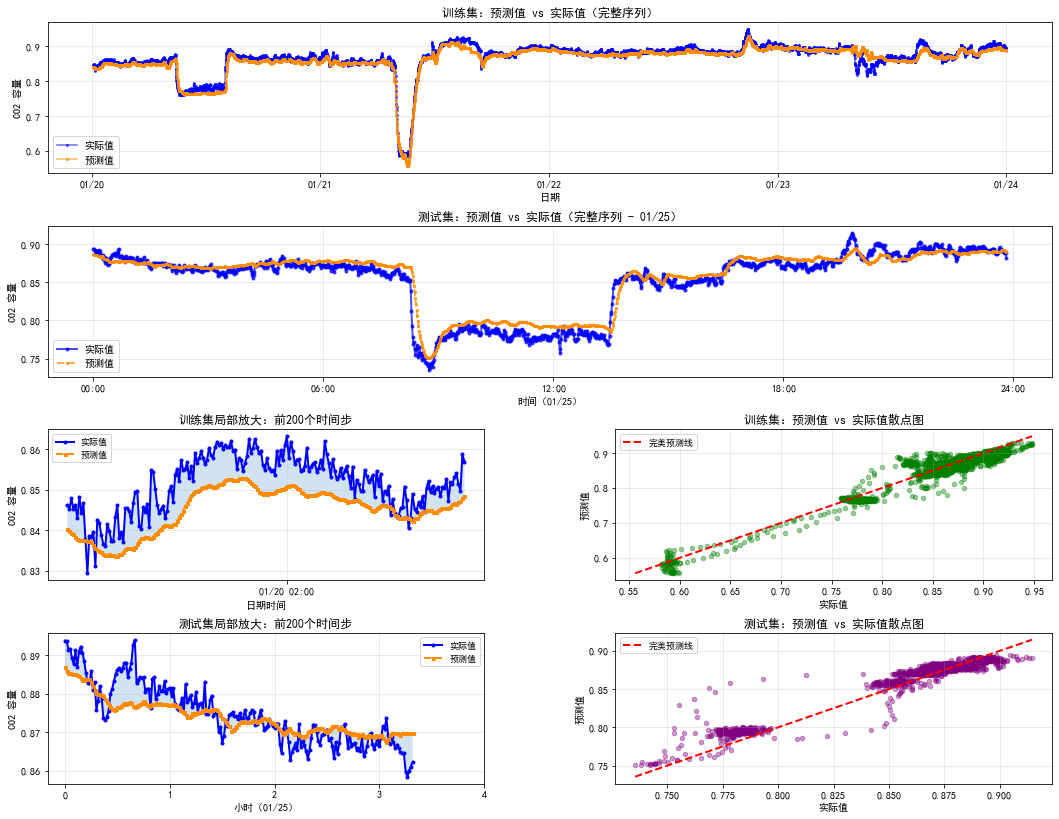

✓ 可视化图表已保存为 'time_series_prediction_results.png'
  • 训练集时间范围：01/20 至 01/23
  • 测试集时间范围：01/24 00:10 至 01/24 23:59 (01/25当天)


In [8]:
# 准备时间序列数据
# 从原始数据中获取实际的时间信息（从第10个时间步开始，因为窗口大小为10）
train_dates_original = time_train.iloc[10:10+len(y_train_windows)]
test_dates_original = time_test.iloc[10:10+len(y_test_windows)]

# 创建大图表 - 包含训练集和测试集
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(4, 2, hspace=0.35, wspace=0.3)

# ==================== 训练集可视化 ====================
# 图 1：训练集时序预测对比（完整序列）
ax1 = fig.add_subplot(gs[0, :])
# 直接使用 pandas datetime 作为横坐标
ax1.plot(train_dates_original, y_train_windows, 'o-', label='实际值', linewidth=1.5, markersize=2, alpha=0.6, color='blue')
ax1.plot(train_dates_original, y_train_pred, 's-', label='预测值', linewidth=1.5, markersize=2, alpha=0.6, color='darkorange')
ax1.set_xlabel('日期', fontweight='bold')
ax1.set_ylabel('CO2 容量', fontweight='bold')
ax1.set_title('训练集：预测值 vs 实际值（完整序列）', fontweight='bold', fontsize=12)
# 使用 matplotlib 日期格式化
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax1.xaxis.set_major_locator(mdates.DayLocator())
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=0, ha='center')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# 图 2：测试集时序预测对比（完整序列）
ax4 = fig.add_subplot(gs[1, :])
# 将测试集时间转换为小时（从0开始）
test_hours = np.arange(len(y_test_windows)) / 60  # 每分钟一个数据点，转换为小时
ax4.plot(test_hours, y_test_windows, 'o-', label='实际值', linewidth=2, markersize=3, alpha=0.7, color='blue')
ax4.plot(test_hours, y_test_pred, 's--', label='预测值', linewidth=2, markersize=2.5, alpha=0.7, color='darkorange')
ax4.set_xlabel('时间（01/25）', fontweight='bold')
ax4.set_ylabel('CO2 容量', fontweight='bold')
ax4.set_title('测试集：预测值 vs 实际值（完整序列 - 01/25）', fontweight='bold', fontsize=12)
# 设置x轴刻度为6小时间隔，从0到24小时，格式为'00:00'
ax4.set_xticks(np.arange(0, max(test_hours)+1, 6))
ax4.set_xticklabels([f'{int(h):02d}:00' for h in np.arange(0, max(test_hours)+1, 6)])
ax4.legend(loc='best', fontsize=10)
ax4.grid(True, alpha=0.3)

# 图 3：训练集局部放大
ax2 = fig.add_subplot(gs[2, 0])
plot_range_train = slice(0, min(200, len(y_train_windows)))
train_local_dates = train_dates_original.iloc[plot_range_train]
ax2.plot(train_local_dates, y_train_windows[plot_range_train], 'o-', label='实际值', linewidth=2, markersize=3, color='blue')
ax2.plot(train_local_dates, y_train_pred[plot_range_train], 's--', label='预测值', linewidth=2, markersize=3, color='darkorange')
ax2.fill_between(train_local_dates, y_train_windows[plot_range_train], y_train_pred[plot_range_train], alpha=0.2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=0, ha='center')
ax2.set_xlabel('日期时间', fontweight='bold')
ax2.set_ylabel('CO2 容量', fontweight='bold')
ax2.set_title('训练集局部放大：前200个时间步', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 图 4：训练集散点图
ax3 = fig.add_subplot(gs[2, 1])
ax3.scatter(y_train_windows, y_train_pred, alpha=0.4, s=20, color='green')
min_val_train = min(y_train_windows.min(), y_train_pred.min())
max_val_train = max(y_train_windows.max(), y_train_pred.max())
ax3.plot([min_val_train, max_val_train], [min_val_train, max_val_train], 'r--', linewidth=2, label='完美预测线')
ax3.set_xlabel('实际值', fontweight='bold')
ax3.set_ylabel('预测值', fontweight='bold')
ax3.set_title('训练集：预测值 vs 实际值散点图', fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 图 5：测试集局部放大
ax5 = fig.add_subplot(gs[3, 0])
plot_range_test = slice(0, min(200, len(y_test_windows)))
test_local_hours = test_hours[plot_range_test]
ax5.plot(test_local_hours, y_test_windows[plot_range_test], 'o-', label='实际值', linewidth=2, markersize=3, color='blue')
ax5.plot(test_local_hours, y_test_pred[plot_range_test], 's--', label='预测值', linewidth=2, markersize=3, color='darkorange')
ax5.fill_between(test_local_hours, y_test_windows[plot_range_test], y_test_pred[plot_range_test], alpha=0.2)
ax5.set_xticks(np.arange(0, max(test_local_hours)+1, 1))  # 每小时一个刻度
ax5.set_xlabel('小时（01/25）', fontweight='bold')
ax5.set_ylabel('CO2 容量', fontweight='bold')
ax5.set_title('测试集局部放大：前200个时间步', fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# 图 6：测试集散点图
ax6 = fig.add_subplot(gs[3, 1])
ax6.scatter(y_test_windows, y_test_pred, alpha=0.4, s=20, color='purple')
min_val_test = min(y_test_windows.min(), y_test_pred.min())
max_val_test = max(y_test_windows.max(), y_test_pred.max())
ax6.plot([min_val_test, max_val_test], [min_val_test, max_val_test], 'r--', linewidth=2, label='完美预测线')
ax6.set_xlabel('实际值', fontweight='bold')
ax6.set_ylabel('预测值', fontweight='bold')
ax6.set_title('测试集：预测值 vs 实际值散点图', fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)

plt.savefig('time_series_prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ 可视化图表已保存为 'time_series_prediction_results.png'")

print(f"  • 训练集时间范围：{train_dates_original.iloc[0].strftime('%m/%d')} 至 {train_dates_original.iloc[-1].strftime('%m/%d')}")
print(f"  • 测试集时间范围：{test_dates_original.iloc[0].strftime('%m/%d %H:%M')} 至 {test_dates_original.iloc[-1].strftime('%m/%d %H:%M')} (01/25当天)")

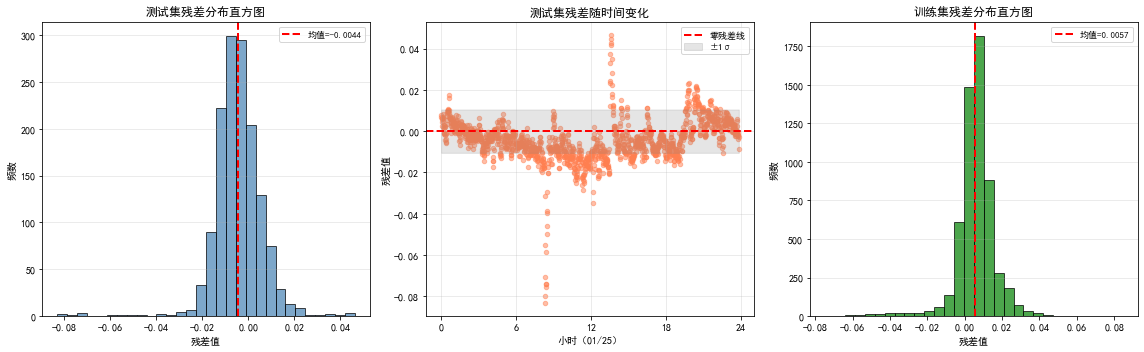

✓ 残差分析图表已保存为 'residual_analysis.png'


In [9]:
# 额外的残差分析图
fig2 = plt.figure(figsize=(16, 5))

# 图 1：测试集残差分布
ax1 = fig2.add_subplot(1, 3, 1)
ax1.hist(residuals, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(residuals_mean, color='red', linestyle='--', linewidth=2, label=f'均值={residuals_mean:.4f}')
ax1.set_xlabel('残差值', fontweight='bold')
ax1.set_ylabel('频数', fontweight='bold')
ax1.set_title('测试集残差分布直方图', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# 图 2：测试集残差随时间变化
ax2 = fig2.add_subplot(1, 3, 2)
# 使用小时作为横坐标
ax2.scatter(test_hours, residuals, alpha=0.5, s=20, color='coral')
ax2.axhline(0, color='red', linestyle='--', linewidth=2, label='零残差线')
ax2.fill_between(test_hours, -residuals_std, residuals_std, alpha=0.2, color='gray', label='±1σ')
ax2.set_xticks(np.arange(0, max(test_hours)+1, 6))  # 每6小时一个刻度
ax2.set_xlabel('小时（01/25）', fontweight='bold')
ax2.set_ylabel('残差值', fontweight='bold')
ax2.set_title('测试集残差随时间变化', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 图 3：训练集残差分布
ax3 = fig2.add_subplot(1, 3, 3)
train_residuals = y_train_windows - y_train_pred
train_residuals_mean = np.mean(train_residuals)
ax3.hist(train_residuals, bins=30, color='green', edgecolor='black', alpha=0.7)
ax3.axvline(train_residuals_mean, color='red', linestyle='--', linewidth=2, label=f'均值={train_residuals_mean:.4f}')
ax3.set_xlabel('残差值', fontweight='bold')
ax3.set_ylabel('频数', fontweight='bold')
ax3.set_title('训练集残差分布直方图', fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ 残差分析图表已保存为 'residual_analysis.png'")

## 第九步：训练过程可视化

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

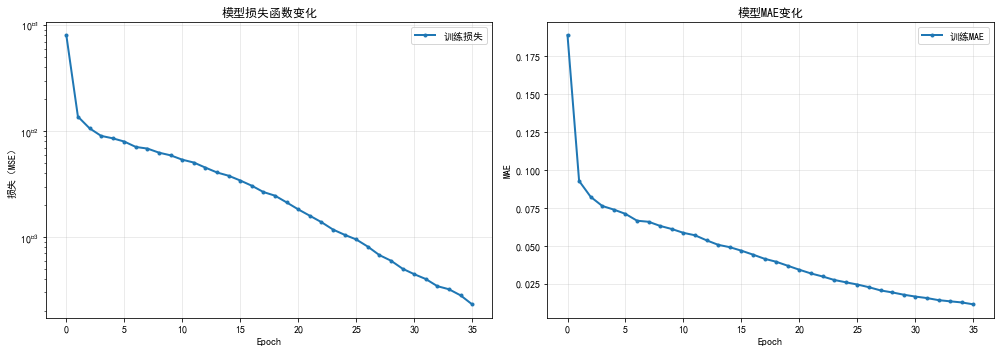

✓ 训练曲线已保存为 'training_history.png'

【训练过程汇总】
  • 总 Epoch 数：36
  • 初始训练损失：0.080377
  • 最终训练损失：0.000232
  • 损失下降比例：99.71%


In [10]:
# 训练历史可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图 1：损失函数变化
ax1 = axes[0]
ax1.plot(history.history['loss'], label='训练损失', linewidth=2, marker='o', markersize=3)
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('损失（MSE）', fontweight='bold')
ax1.set_title('模型损失函数变化', fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# 图 2：MAE变化
ax2 = axes[1]
ax2.plot(history.history['mae'], label='训练MAE', linewidth=2, marker='o', markersize=3)
ax2.set_xlabel('Epoch', fontweight='bold')
ax2.set_ylabel('MAE', fontweight='bold')
ax2.set_title('模型MAE变化', fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ 训练曲线已保存为 'training_history.png'")

# 训练汇总
print("\n【训练过程汇总】")
print(f"  • 总 Epoch 数：{len(history.history['loss'])}")
print(f"  • 初始训练损失：{history.history['loss'][0]:.6f}")
print(f"  • 最终训练损失：{history.history['loss'][-1]:.6f}")
print(f"  • 损失下降比例：{(1 - history.history['loss'][-1] / history.history['loss'][0]) * 100:.2f}%")

## 第十步：结果汇总与保存

In [11]:
# 创建汇总报告
summary_report = f"""
{'='*80}
时序预测模型性能总结报告（LSTM神经网络）
{'='*80}

【数据配置】
  • 原始数据点数：{len(df)}
  • 采样频率：1 分钟/条
  • 时间跨度：约 {len(df)} 分钟
  • 选定特征数：{len(selected_features)}

【数据分割】
  • 训练集：{len(X_train_raw)} 条（前 80%）
  • 测试集：{len(X_test_raw)} 条（后 20%）
  • 训练窗口数：{len(X_train_windows)}（每个窗口 10 分钟）
  • 测试窗口数：{len(X_test_windows)}（每个窗口 10 分钟）

【模型配置】
  • 模型类型：LSTM神经网络
  • 输入形状：(样本数, 10时间步, 10特征)
  • 隐藏层1：LSTM 64个神经元 + Dropout(0.4) + return_sequences=True
  • 隐藏层2：LSTM 64个神经元 + Dropout(0.4)
  • 输出层：Dense 1个神经元
  • 优化器：Adam(learning_rate=0.001)
  • 损失函数：MSE(均方误差)
  • 预测任务：前 10 分钟 → 下 1 分钟

【训练配置】
  • 批量大小：32
  • Epoch 数量：150（配合Early Stopping）
  • 实际训练 Epoch：{len(history.history['loss'])}
  • Early Stopping：监控训练损失，耐心值=20
  • 数据打乱：否（保持时序完整性）

【性能指标】

  训练集：
    • R²：{train_r2:.4f}
    • RMSE：{train_rmse:.6f}
    • MAE：{train_mae:.6f}

  测试集：
    • R²：{test_r2:.4f}
    • RMSE：{test_rmse:.6f}
    • MAE：{test_mae:.6f}
    • MAPE：{test_mape:.2f}%
    • WQL：{test_wql:.6f}

【预测精度解释】
  • R² = {test_r2:.4f}：模型解释了测试集 {test_r2*100:.2f}% 的目标变量方差
  • RMSE = {test_rmse:.6f}：平均预测误差（在原始数据尺度上）
  • MAE = {test_mae:.6f}：平均绝对偏差
  • MAPE = {test_mape:.2f}%：平均绝对百分比误差
  • WQL = {test_wql:.6f}：加权分位数损失（评估不同分位数下的表现）

【残差分析】
  • 残差均值：{residuals_mean:.6f}（接近 0 表示预测无偏）
  • 残差标准差：{residuals_std:.6f}
  • 残差范围：[{residuals.min():.6f}, {residuals.max():.6f}]

【训练过程】
  • 初始训练损失：{history.history['loss'][0]:.6f}
  • 最终训练损失：{history.history['loss'][-1]:.6f}
  • 损失下降比例：{(1 - history.history['loss'][-1] / history.history['loss'][0]) * 100:.2f}%

{'='*80}
"""

print(summary_report)

# 保存报告
with open('time_series_prediction_report.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)
print("✓ 报告已保存为 'time_series_prediction_report.txt'")


时序预测模型性能总结报告（LSTM神经网络）

【数据配置】
  • 原始数据点数：7200
  • 采样频率：1 分钟/条
  • 时间跨度：约 7200 分钟
  • 选定特征数：11

【数据分割】
  • 训练集：5760 条（前 80%）
  • 测试集：1440 条（后 20%）
  • 训练窗口数：5750（每个窗口 10 分钟）
  • 测试窗口数：1430（每个窗口 10 分钟）

【模型配置】
  • 模型类型：LSTM神经网络
  • 输入形状：(样本数, 10时间步, 10特征)
  • 隐藏层1：LSTM 64个神经元 + Dropout(0.4) + return_sequences=True
  • 隐藏层2：LSTM 64个神经元 + Dropout(0.4)
  • 输出层：Dense 1个神经元
  • 优化器：Adam(learning_rate=0.001)
  • 损失函数：MSE(均方误差)
  • 预测任务：前 10 分钟 → 下 1 分钟

【训练配置】
  • 批量大小：32
  • Epoch 数量：150（配合Early Stopping）
  • 实际训练 Epoch：36
  • Early Stopping：监控训练损失，耐心值=20
  • 数据打乱：否（保持时序完整性）

【性能指标】

  训练集：
    • R²：0.9287
    • RMSE：0.012402
    • MAE：0.008945

  测试集：
    • R²：0.9251
    • RMSE：0.011381
    • MAE：0.008266
    • MAPE：0.99%
    • WQL：0.004133

【预测精度解释】
  • R² = 0.9251：模型解释了测试集 92.51% 的目标变量方差
  • RMSE = 0.011381：平均预测误差（在原始数据尺度上）
  • MAE = 0.008266：平均绝对偏差
  • MAPE = 0.99%：平均绝对百分比误差
  • WQL = 0.004133：加权分位数损失（评估不同分位数下的表现）

【残差分析】
  • 残差均值：-0.004406（接近 0 表示预测无偏）
  • 残差标准差：0.010493
  • 残差范围：[-0.0

In [12]:
# 保存预测结果为 CSV
results_df = pd.DataFrame({
    '时间步': np.arange(len(y_test_windows)),
    '实际值': y_test_windows,
    '预测值': y_test_pred,
    '残差': residuals,
    '绝对误差': np.abs(residuals),
    '相对误差(%)': np.abs(residuals) / np.abs(y_test_windows) * 100
})

results_df.to_csv('time_series_predictions.csv', index=False, encoding='utf-8-sig')
print("✓ 预测结果已保存为 'time_series_predictions.csv'")

# 保存性能指标汇总
metrics_summary = pd.DataFrame({
    '指标': ['R²', 'RMSE', 'MAE', 'MAPE(%)', 'WQL', '残差均值', '残差标准差'],
    '训练集': [train_r2, train_rmse, train_mae, np.nan, np.nan, np.nan, np.nan],
    '测试集': [test_r2, test_rmse, test_mae, test_mape, test_wql, residuals_mean, residuals_std]
})

metrics_summary.to_csv('performance_metrics.csv', index=False, encoding='utf-8-sig')
print("✓ 性能指标已保存为 'performance_metrics.csv'")

# 保存模型
model.save('lstm_model.h5')
print("✓ LSTM模型已保存为 'lstm_model.h5'")

print("\n" + "="*80)
print("✅ 所有文件生成完成！")
print("="*80)
print("\n生成的文件：")
print("  1. time_series_prediction_results.png - 预测结果可视化（5 个子图）")
print("  2. training_history.png - 训练过程可视化（损失和MAE曲线）")
print("  3. time_series_prediction_report.txt - 性能汇总报告")
print("  4. time_series_predictions.csv - 详细预测结果")
print("  5. performance_metrics.csv - 性能指标汇总")
print("  6. lstm_model.h5 - 训练好的LSTM模型")

✓ 预测结果已保存为 'time_series_predictions.csv'
✓ 性能指标已保存为 'performance_metrics.csv'
✓ LSTM模型已保存为 'lstm_model.h5'

✅ 所有文件生成完成！

生成的文件：
  1. time_series_prediction_results.png - 预测结果可视化（5 个子图）
  2. training_history.png - 训练过程可视化（损失和MAE曲线）
  3. time_series_prediction_report.txt - 性能汇总报告
  4. time_series_predictions.csv - 详细预测结果
  5. performance_metrics.csv - 性能指标汇总
  6. lstm_model.h5 - 训练好的LSTM模型


## 第八步：SHAP可解释性分析

**SHAP (SHapley Additive exPlanations)** 是一种模型可解释性工具,用于解释机器学习模型的预测结果。

### 📊 两种重要图表：

1. **总结图 (Summary Plot)** - 全局视角
   - 展示所有特征对模型预测的整体影响
   - 横轴：SHAP值（特征贡献）
   - 纵轴：特征名称（按重要性排序）
   - 颜色：特征值高低（红=高，蓝=低）
   - **用途**：找出最重要的特征，了解特征如何影响预测

2. **瀑布图 (Waterfall Plot)** - 单样本视角
   - 展示单个预测是如何计算出来的
   - 从基准值开始，逐步累加每个特征的贡献
   - 红色：正向贡献（推高预测）
   - 蓝色：负向贡献（拉低预测）
   - **用途**：解释具体某个时刻的预测结果，诊断异常

In [13]:
# 第1步：安装并导入SHAP库
print("="*80)
print("准备SHAP分析环境")
print("="*80)

# 检查SHAP是否已安装
try:
    import shap
    print(f"✓ SHAP库已安装，版本：{shap.__version__}")
except ImportError:
    print("⚠ SHAP库未安装，正在安装...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap
    print(f"✓ SHAP库安装完成，版本：{shap.__version__}")

print("✓ SHAP分析环境准备完成")

准备SHAP分析环境
✓ SHAP库已安装，版本：0.48.0
✓ SHAP分析环境准备完成


In [14]:
# 第2步：将3D数据转换为2D格式（用于SHAP分析）
print("\n" + "="*80)
print("准备SHAP分析数据（将3D时间窗口展平为2D）")
print("="*80)

# LSTM的输入是3D：(样本数, 时间步=10, 特征数=11)
# SHAP需要2D数据，将每个时间窗口展平为一维向量
print(f"\n原始数据形状：")
print(f"  • X_train_lstm：{X_train_lstm.shape} (样本数, 时间步, 特征数)")
print(f"  • X_test_lstm：{X_test_lstm.shape}")

# 重塑3D数据为2D：(样本数, 时间步×特征数)
X_train_flat = X_train_lstm.reshape(X_train_lstm.shape[0], -1)
X_test_flat = X_test_lstm.reshape(X_test_lstm.shape[0], -1)

print(f"\n展平后数据形状：")
print(f"  • X_train_flat：{X_train_flat.shape} (样本数, 10时间步 × {len(selected_features)}特征)")
print(f"  • X_test_flat：{X_test_flat.shape}")

# 生成特征名称：每个原始特征在10个时间步上的名称
feature_names = []
for t in range(10, 0, -1):  # 从 t-10 到 t-1
    for feat in selected_features:
        feature_names.append(f'{feat}_t-{t}')

print(f"\n✓ 生成了 {len(feature_names)} 个特征名称")
print(f"  示例前5个：{feature_names[:5]}")
print(f"  示例后5个：{feature_names[-5:]}")

# 创建带特征名的DataFrame（用于SHAP分析）
X_train_df = pd.DataFrame(X_train_flat, columns=feature_names)
X_test_df = pd.DataFrame(X_test_flat, columns=feature_names)

print(f"\n✓ 创建DataFrame完成")
print(f"  • 训练集：{X_train_df.shape}")
print(f"  • 测试集：{X_test_df.shape}")


准备SHAP分析数据（将3D时间窗口展平为2D）

原始数据形状：
  • X_train_lstm：(5750, 10, 11) (样本数, 时间步, 特征数)
  • X_test_lstm：(1430, 10, 11)

展平后数据形状：
  • X_train_flat：(5750, 110) (样本数, 10时间步 × 11特征)
  • X_test_flat：(1430, 110)

✓ 生成了 110 个特征名称
  示例前5个：['TI-34_t-10', 'TI-33_t-10', 'FI-30_t-10', 'FI-38_t-10', 'TI-4_t-10']
  示例后5个：['TI-12_t-1', 'TI-22_t-1', 'TI-24_t-1', 'TI-28_t-1', 'Level Reboiler_t-1']

✓ 创建DataFrame完成
  • 训练集：(5750, 110)
  • 测试集：(1430, 110)


In [15]:
# 第3步：创建SHAP Explainer（专门用于深度学习模型）
print("\n" + "="*80)
print("创建SHAP Explainer")
print("="*80)

# 确保必要的库已导入
try:
    import numpy as np
    import pandas as pd
except ImportError as e:
    raise ImportError(f"缺少必要的库：{e}。请先运行第1个单元格导入所有库！")

# 检查模型是否已经训练
try:
    model
    print("✓ 检测到已训练的模型")
except NameError:
    print("⚠ 模型未训练，尝试加载保存的模型...")
    from tensorflow.keras.models import load_model
    try:
        model = load_model('lstm_model.h5')
        print("✓ 成功加载已保存的模型：lstm_model.h5")
    except:
        raise RuntimeError("❌ 模型未找到！请先运行前面的单元格训练模型，或确保 lstm_model.h5 文件存在。")

# 检查必要的数据变量
try:
    X_train_lstm
    X_test_lstm
    print("✓ 检测到训练和测试数据")
except NameError:
    raise RuntimeError("❌ 数据变量未定义！请先运行前面的单元格准备数据（第1-10个单元格）。")

# 由于LSTM是深度学习模型，选择背景数据集（随机抽取100个样本加速计算）
np.random.seed(42)
background_indices = np.random.choice(len(X_train_lstm), size=min(100, len(X_train_lstm)), replace=False)
background_data = X_train_lstm[background_indices]

print(f"✓ 背景数据集：{background_data.shape}")
print(f"  • 样本数：{background_data.shape[0]}")
print(f"  • 时间步：{background_data.shape[1]}")
print(f"  • 特征数：{background_data.shape[2]}")

# 创建 KernelExplainer
print(f"\n创建 KernelExplainer...")
print(f"⚠ 注意：KernelExplainer 是模型无关的方法，计算较慢但最可靠")

def model_predict(x):
    """包装模型预测函数，处理2D->3D的转换"""
    if len(x.shape) == 2:
        # 从2D (samples, 110) 转换为3D (samples, 10, 11)
        x = x.reshape(x.shape[0], 10, 11)
    return model.predict(x, verbose=0)

# 使用较小的背景数据集（50个样本）加速计算
small_background = background_data[:50]
small_background_2d = small_background.reshape(small_background.shape[0], -1)

explainer = shap.KernelExplainer(model_predict, small_background_2d)

print(f"✓ KernelExplainer 创建完成")
print(f"  • 模型类型：LSTM神经网络")
print(f"  • 背景样本：{small_background.shape[0]}")
print(f"  • 输入形状：2D ({small_background_2d.shape[1]}维)")
print(f"  • 说明：模型无关的SHAP解释器，通过采样估计SHAP值")
print(f"  • 优点：不依赖梯度计算，与TensorFlow版本无关")
print(f"  • 缺点：计算速度较慢（每个样本约需几秒到几十秒）")


创建SHAP Explainer
✓ 检测到已训练的模型
✓ 检测到训练和测试数据
✓ 背景数据集：(100, 10, 11)
  • 样本数：100
  • 时间步：10
  • 特征数：11

创建 KernelExplainer...
⚠ 注意：KernelExplainer 是模型无关的方法，计算较慢但最可靠
✓ KernelExplainer 创建完成
  • 模型类型：LSTM神经网络
  • 背景样本：50
  • 输入形状：2D (110维)
  • 说明：模型无关的SHAP解释器，通过采样估计SHAP值
  • 优点：不依赖梯度计算，与TensorFlow版本无关
  • 缺点：计算速度较慢（每个样本约需几秒到几十秒）


In [16]:
# 第4步：合并训练集和测试集，统一抽取1000个样本计算SHAP值
print("\n" + "="*80)
print("合并数据集并计算SHAP值")
print("="*80)

# 合并训练集和测试集
print(f"\n【数据集合并】")
print(f"  • 训练集样本数：{len(X_train_lstm)}")
print(f"  • 测试集样本数：{len(X_test_lstm)}")

X_all = np.concatenate([X_train_lstm, X_test_lstm], axis=0)
y_all = np.concatenate([y_train_windows, y_test_windows], axis=0)

print(f"  • 合并后总样本数：{len(X_all)}")

# 从合并后的数据集中随机抽取1000个样本
sample_size = min(1000, len(X_all))
np.random.seed(42)
sample_indices = np.random.choice(len(X_all), size=sample_size, replace=False)
X_sample = X_all[sample_indices]
y_sample_true = y_all[sample_indices]

print(f"\n【样本抽取】")
print(f"  • 抽取样本数：{sample_size}")
print(f"  ⏱ 预计耗时：约 {sample_size * 0.5 / 60:.1f} 分钟")
print(f"  💡 使用KernelExplainer（较慢但稳定）")

print(f"\n正在计算 {sample_size} 个样本的SHAP值...")
print(f"  （使用 KernelExplainer，请耐心等待...）")

# KernelExplainer需要2D输入
X_sample_input = X_sample.reshape(X_sample.shape[0], -1)
shap_values_raw = explainer.shap_values(X_sample_input, nsamples=100)

# 处理返回值（可能是列表或数组）
if isinstance(shap_values_raw, list):
    shap_values_raw = shap_values_raw[0]

# 确保是2D形状
if len(shap_values_raw.shape) == 2:
    shap_values = shap_values_raw
else:
    # 3D形状，展平为2D：(样本数, 时间步×特征数)
    shap_values = shap_values_raw.reshape(shap_values_raw.shape[0], -1)

print(f"✓ SHAP值计算完成")
print(f"  • 原始SHAP值形状：{shap_values_raw.shape}")
print(f"  • 展平后形状：{shap_values.shape}")

# 计算基准值（样本的平均预测）
y_sample_pred = model.predict(X_sample, verbose=0).flatten()
expected_value = y_sample_pred.mean()
print(f"  • 基准值（Expected value）：{expected_value:.6f}")
print(f"  • 预测值范围：[{y_sample_pred.min():.6f}, {y_sample_pred.max():.6f}]")
print(f"  • 实际值范围：[{y_sample_true.min():.6f}, {y_sample_true.max():.6f}]")
    




合并数据集并计算SHAP值

【数据集合并】
  • 训练集样本数：5750
  • 测试集样本数：1430
  • 合并后总样本数：7180

【样本抽取】
  • 抽取样本数：1000
  ⏱ 预计耗时：约 8.3 分钟
  💡 使用KernelExplainer（较慢但稳定）

正在计算 1000 个样本的SHAP值...
  （使用 KernelExplainer，请耐心等待...）


100%|██████████| 1000/1000 [10:44<00:00,  1.55it/s]

✓ SHAP值计算完成
  • 原始SHAP值形状：(1000, 110, 1)
  • 展平后形状：(1000, 110)
  • 基准值（Expected value）：0.860369
  • 预测值范围：[0.556049, 0.928958]
  • 实际值范围：[0.582062, 0.947201]



绘制SHAP总结图（按原始特征聚合）
✓ SHAP值已按11个原始特征聚合
  • 聚合后形状：(1000, 11)


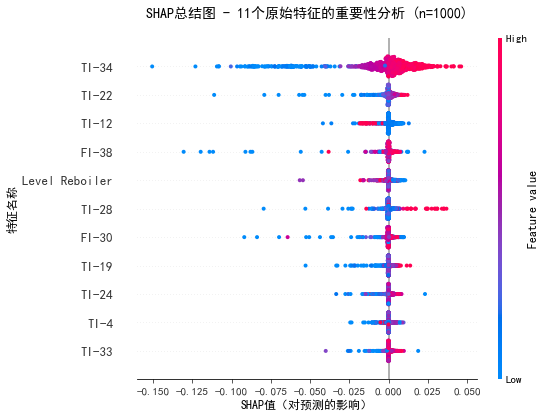

✓ SHAP总结图已保存：shap_summary_plot_combined.png

【图表说明】
  • 样本来源：训练集 + 测试集合并后随机抽取1000个
  • 横轴：SHAP值（特征对预测的贡献，正值推高预测，负值拉低预测）
  • 纵轴：11个原始特征名称（按重要性从上到下排序）
  • 颜色：特征值大小（红色=高值，蓝色=低值）
  • 说明：每个特征的SHAP值是其在10个时间步上的总和
  • 用途：识别最重要的特征，了解特征值如何影响CO2容量预测


In [17]:
# 第5步：绘制SHAP总结图（按11个原始特征聚合）
print("\n" + "="*80)
print("绘制SHAP总结图（按原始特征聚合）")
print("="*80)

# 将110维SHAP值按11个原始特征聚合
shap_values_aggregated = np.zeros((shap_values.shape[0], len(selected_features)))
X_sample_flat = X_sample.reshape(X_sample.shape[0], -1)
X_aggregated = np.zeros((X_sample.shape[0], len(selected_features)))

for i, feat in enumerate(selected_features):
    # 找到该特征在不同时间步的所有列索引
    feat_indices = [idx for idx, name in enumerate(feature_names) if name.startswith(feat + '_')]
    # 聚合SHAP值（求和）
    shap_values_aggregated[:, i] = shap_values[:, feat_indices].sum(axis=1)
    # 聚合特征值（取平均）
    X_aggregated[:, i] = X_sample_flat[:, feat_indices].mean(axis=1)

print(f"✓ SHAP值已按{len(selected_features)}个原始特征聚合")
print(f"  • 聚合后形状：{shap_values_aggregated.shape}")

# 绘制聚合后的总结图
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(
    shap_values_aggregated, 
    pd.DataFrame(X_aggregated, columns=selected_features),
    show=False
)
plt.title(f'SHAP总结图 - {len(selected_features)}个原始特征的重要性分析 (n={len(X_sample)})', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('SHAP值（对预测的影响）', fontsize=12, fontweight='bold')
plt.ylabel('特征名称', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_plot_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ SHAP总结图已保存：shap_summary_plot_combined.png")
print(f"\n【图表说明】")
print(f"  • 样本来源：训练集 + 测试集合并后随机抽取1000个")
print(f"  • 横轴：SHAP值（特征对预测的贡献，正值推高预测，负值拉低预测）")
print(f"  • 纵轴：{len(selected_features)}个原始特征名称（按重要性从上到下排序）")
print(f"  • 颜色：特征值大小（红色=高值，蓝色=低值）")
print(f"  • 说明：每个特征的SHAP值是其在10个时间步上的总和")
print(f"  • 用途：识别最重要的特征，了解特征值如何影响CO2容量预测")

In [18]:
# 原第7步已删除：不再单独绘制测试集SHAP总结图
# 现在使用合并数据集的统一SHAP总结图

In [19]:
# 第6步：选择典型样本绘制瀑布图
print("\n" + "="*80)
print("选择典型样本绘制SHAP瀑布图")
print("="*80)

# 从1000个已计算SHAP值的样本中选择典型样本
print(f"⚠ 从 {len(X_sample)} 个合并样本中选择典型样本")

# 计算预测误差
errors = y_sample_true - y_sample_pred
abs_errors = np.abs(errors)

# 选择3个典型样本
max_actual_idx = np.argmax(y_sample_true)
min_actual_idx = np.argmin(y_sample_true)
min_error_idx = np.argmin(abs_errors)

typical_samples = [
    ('实际值最大点', max_actual_idx, 'blue'),
    ('实际值最小点', min_actual_idx, 'purple'),
    ('预测最准的点', min_error_idx, 'green')
]

print(f"\n已选择3个典型样本：")
for name, idx, color in typical_samples:
    print(f"  • {name}：样本索引={idx}, 实际值={y_sample_true[idx]:.6f}, "
          f"预测值={y_sample_pred[idx]:.6f}, 误差={errors[idx]:.6f}")


选择典型样本绘制SHAP瀑布图
⚠ 从 1000 个合并样本中选择典型样本

已选择3个典型样本：
  • 实际值最大点：样本索引=443, 实际值=0.947201, 预测值=0.924678, 误差=0.022523
  • 实际值最小点：样本索引=839, 实际值=0.582062, 预测值=0.582593, 误差=-0.000531
  • 预测最准的点：样本索引=771, 实际值=0.887878, 预测值=0.887897, 误差=-0.000019



绘制SHAP瀑布图（3个典型样本，按11个原始特征聚合）

【SHAP值统计信息】
  • 基准值（Expected value）：0.860369
  • 合并样本预测值范围：[0.556049, 0.928958]
  • 合并样本实际值范围：[0.582062, 0.947201]

【SHAP值验证（第1个样本）】
  • 基准值：0.860369
  • 所有SHAP值之和：-0.016698
  • 基准值 + SHAP和：0.843671
  • 实际预测值：0.848037
  • 差异：0.004366

正在绘制第 1 张图：实际值最大点...

【聚合后的SHAP值（第1个典型样本：实际值最大点）】
  • 聚合后SHAP值范围：[-0.002383, 0.046310]
  • 聚合后SHAP值总和：0.059943
  • 各特征的SHAP值：
      TI-34          :   0.046310
      TI-33          :   0.000000
      FI-30          :   0.000000
      FI-38          :   0.000000
      TI-4           :   0.000000
      TI-19          :  -0.002383
      TI-12          :   0.009526
      TI-22          :   0.003827
      TI-24          :   0.002664
      TI-28          :   0.000000
      Level Reboiler :   0.000000


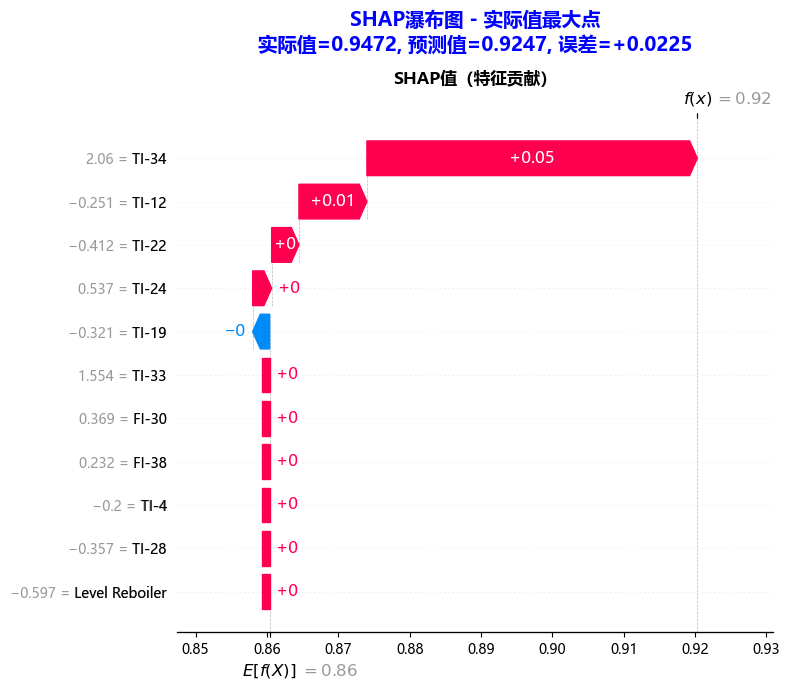

  ✓ 已保存：shap_waterfall_1_实际值最大点.png

正在绘制第 2 张图：实际值最小点...


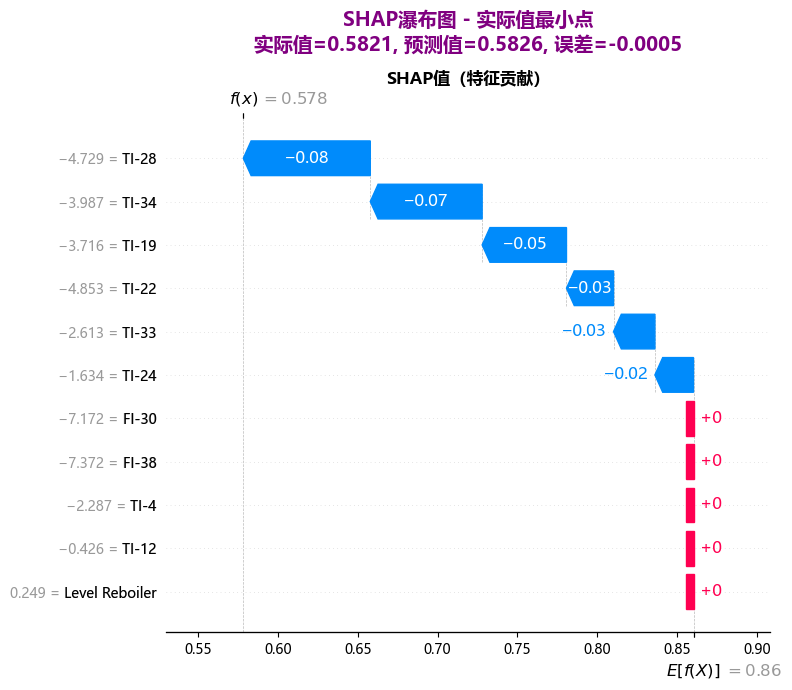

  ✓ 已保存：shap_waterfall_2_实际值最小点.png

正在绘制第 3 张图：预测最准的点...


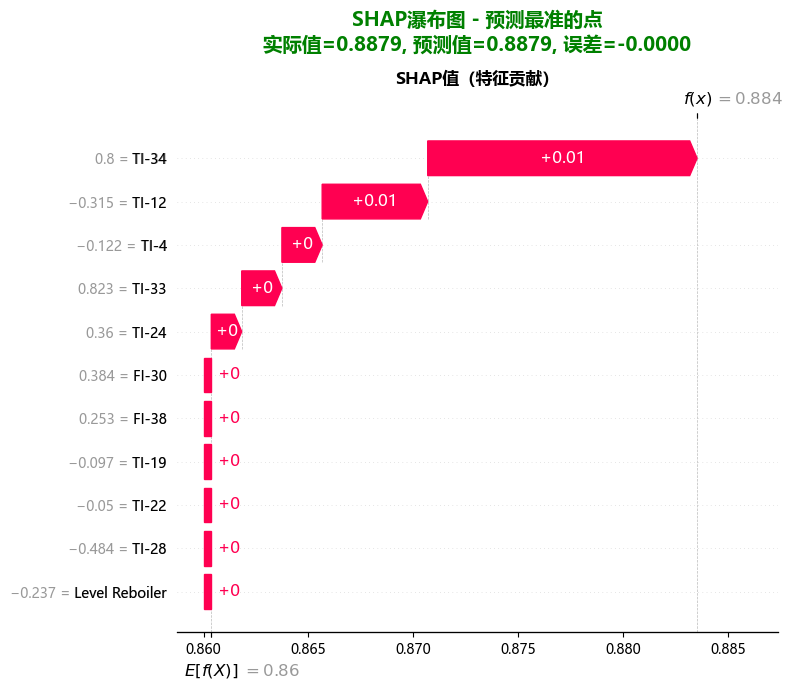

  ✓ 已保存：shap_waterfall_3_预测最准的点.png

✓ 所有SHAP瀑布图已保存：
    - shap_waterfall_1_实际值最大点.png
    - shap_waterfall_2_实际值最小点.png
    - shap_waterfall_3_预测最准的点.png

【图表说明】
  • E[f(x)]：基准值（所有样本的平均预测值=0.8604）
  • f(x)：该样本的实际预测值
  • 红色条：正向贡献（推高预测）
  • 蓝色条：负向贡献（拉低预测）
  • 误差：正值表示高估（预测>实际），负值表示低估（预测<实际）
  • 用途：解释单个预测的计算过程，诊断异常样本

【样本类型】
  • 实际值最大点：CO2容量最高的样本，了解高容量时的特征影响
  • 实际值最小点：CO2容量最低的样本，了解低容量时的特征影响
  • 预测最准的点：误差最小的样本，了解模型预测最佳时的情况


In [20]:
# 第7步：绘制瀑布图（3个典型样本，按11个原始特征聚合）
print("\n" + "="*80)
print(f"绘制SHAP瀑布图（3个典型样本，按{len(selected_features)}个原始特征聚合）")
print("="*80)

# 设置白色背景样式
plt.style.use('default')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# 打印SHAP值的统计信息
print(f"\n【SHAP值统计信息】")
print(f"  • 基准值（Expected value）：{expected_value:.6f}")
print(f"  • 合并样本预测值范围：[{y_sample_pred.min():.6f}, {y_sample_pred.max():.6f}]")
print(f"  • 合并样本实际值范围：[{y_sample_true.min():.6f}, {y_sample_true.max():.6f}]")

# 验证第一个样本的SHAP值
idx_check = 0
shap_sum_check = shap_values[idx_check].sum()
pred_check = y_sample_pred[idx_check]
print(f"\n【SHAP值验证（第1个样本）】")
print(f"  • 基准值：{expected_value:.6f}")
print(f"  • 所有SHAP值之和：{shap_sum_check:.6f}")
print(f"  • 基准值 + SHAP和：{expected_value + shap_sum_check:.6f}")
print(f"  • 实际预测值：{pred_check:.6f}")
print(f"  • 差异：{abs((expected_value + shap_sum_check) - pred_check):.6f}")

# 为每个典型样本绘制单独的瀑布图
saved_files = []
for i, (name, idx, color) in enumerate(typical_samples, 1):
    print(f"\n正在绘制第 {i} 张图：{name}...")
    
    # 创建新的独立图形
    fig = plt.figure(figsize=(10, 8))
    fig.patch.set_facecolor('white')
    ax = plt.gca()
    ax.set_facecolor('white')
    
    # 对该样本的SHAP值按11个原始特征聚合
    shap_values_aggregated_sample = np.zeros(len(selected_features))
    X_aggregated_sample = np.zeros(len(selected_features))
    
    # 获取该样本对应的展平特征（使用X_sample_flat，因为它对应已计算SHAP值的样本）
    sample_flat = X_sample_flat[idx]
    
    for j, feat in enumerate(selected_features):
        # 找到该特征在不同时间步的所有列索引
        feat_indices = [k for k, name_k in enumerate(feature_names) if name_k.startswith(feat + '_')]
        # 聚合SHAP值（求和）
        shap_values_aggregated_sample[j] = shap_values[idx, feat_indices].sum()
        # 聚合特征值（取平均）
        X_aggregated_sample[j] = sample_flat[feat_indices].mean()
    
    # 打印聚合后的SHAP值信息（只打印第一个样本）
    if i == 1:
        print(f"\n【聚合后的SHAP值（第1个典型样本：{name}）】")
        print(f"  • 聚合后SHAP值范围：[{shap_values_aggregated_sample.min():.6f}, {shap_values_aggregated_sample.max():.6f}]")
        print(f"  • 聚合后SHAP值总和：{shap_values_aggregated_sample.sum():.6f}")
        print(f"  • 各特征的SHAP值：")
        for feat_name, shap_val in zip(selected_features, shap_values_aggregated_sample):
            print(f"      {feat_name:<15}: {shap_val:>10.6f}")
    
    # 创建SHAP Explanation对象（使用聚合后的11个特征）
    shap_exp = shap.Explanation(
        values=shap_values_aggregated_sample,
        base_values=expected_value,
        data=X_aggregated_sample,
        feature_names=selected_features
    )
    
    # 绘制瀑布图
    shap.waterfall_plot(shap_exp, max_display=len(selected_features), show=False)
    
    # 添加中文标题和说明
    actual = y_sample_true[idx]
    pred = y_sample_pred[idx]
    error = errors[idx]
    
    # 根据样本类型设置不同的标题颜色
    plt.title(f'SHAP瀑布图 - {name}\n实际值={actual:.4f}, 预测值={pred:.4f}, 误差={error:+.4f}',
              fontsize=14, fontweight='bold', color=color, pad=15)
    plt.xlabel('SHAP值（特征贡献）', fontsize=12, fontweight='bold')
    plt.ylabel('特征', fontsize=12, fontweight='bold')
    
    # 调整字体大小
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    # 保存为单独的文件
    filename = f'shap_waterfall_{i}_{name.replace(" ", "_")}.png'
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    saved_files.append(filename)
    print(f"  ✓ 已保存：{filename}")
    
    # 关闭当前图形释放内存
    plt.close(fig)

print(f"\n✓ 所有SHAP瀑布图已保存：")
for filename in saved_files:
    print(f"    - {filename}")

print(f"\n【图表说明】")
print(f"  • E[f(x)]：基准值（所有样本的平均预测值={expected_value:.4f}）")
print(f"  • f(x)：该样本的实际预测值")
print(f"  • 红色条：正向贡献（推高预测）")
print(f"  • 蓝色条：负向贡献（拉低预测）")
print(f"  • 误差：正值表示高估（预测>实际），负值表示低估（预测<实际）")
print(f"  • 用途：解释单个预测的计算过程，诊断异常样本")
print(f"\n【样本类型】")
print(f"  • 实际值最大点：CO2容量最高的样本，了解高容量时的特征影响")
print(f"  • 实际值最小点：CO2容量最低的样本，了解低容量时的特征影响")
print(f"  • 预测最准的点：误差最小的样本，了解模型预测最佳时的情况")

In [ ]:
# 第10步：SHAP分析总结报告
print("\n" + "="*80)
print("SHAP分析总结报告")
print("="*80)

# 先分离出训练集和测试集的SHAP值
# sample_indices 包含了从合并数据集中抽取的样本索引
train_size = len(X_train_lstm)
train_mask = sample_indices < train_size
test_mask = sample_indices >= train_size

shap_values_train_aggregated = shap_values_aggregated[train_mask]
shap_values_test_aggregated = shap_values_aggregated[test_mask]

print(f"\n【SHAP值分离】")
print(f"  • 训练集样本数：{shap_values_train_aggregated.shape[0]}")
print(f"  • 测试集样本数：{shap_values_test_aggregated.shape[0]}")
print(f"  • 总样本数：{shap_values_aggregated.shape[0]}")

# 计算平均绝对SHAP值，找出最重要的特征
mean_abs_shap_train = np.abs(shap_values_train_aggregated).mean(axis=0)
mean_abs_shap_test = np.abs(shap_values_test_aggregated).mean(axis=0)

# 按重要性排序
top_n = len(selected_features)
train_top_indices = np.argsort(mean_abs_shap_train)[::-1][:top_n]
test_top_indices = np.argsort(mean_abs_shap_test)[::-1][:top_n]

print(f"\n【训练集】Top {top_n} 最重要特征（按平均|SHAP值|排序）：")
for rank, idx in enumerate(train_top_indices, 1):
    print(f"  {rank}. {selected_features[idx]:<20} | 平均|SHAP|={mean_abs_shap_train[idx]:.6f}")

print(f"\n【测试集】Top {top_n} 最重要特征（按平均|SHAP值|排序）：")
for rank, idx in enumerate(test_top_indices, 1):
    print(f"  {rank}. {selected_features[idx]:<20} | 平均|SHAP|={mean_abs_shap_test[idx]:.6f}")

# 保存SHAP重要性到CSV
shap_importance_df = pd.DataFrame({
    '特征名称': selected_features,
    '训练集_平均绝对SHAP值': mean_abs_shap_train,
    '测试集_平均绝对SHAP值': mean_abs_shap_test
})
shap_importance_df = shap_importance_df.sort_values('测试集_平均绝对SHAP值', ascending=False)
shap_importance_df.to_csv('shap_feature_importance.csv', index=False, encoding='utf-8-sig')

print(f"\n✓ SHAP特征重要性已保存：shap_feature_importance.csv")

print("\n" + "="*80)
print("✅ SHAP分析完成！")
print("="*80)
print("\n生成的文件：")
print("  1. shap_summary_plot_combined.png - 合并数据集SHAP总结图")
print("  2. shap_waterfall_*.png - 典型样本瀑布图（3个）")
print("  3. shap_feature_importance.csv - SHAP特征重要性排名")

print("\n【SHAP分析总结】")
print(f"  • LSTM模型使用KernelExplainer进行SHAP分析")
print(f"  • 训练集样本数：{shap_values_train_aggregated.shape[0]}（从抽样中分离）")
print(f"  • 测试集样本数：{shap_values_test_aggregated.shape[0]}（从抽样中分离）")
print(f"  • 总样本数：{sample_size}（从合并数据集抽样）")
print(f"  • 特征维度：{len(selected_features)}个原始特征 × 10个时间步 = {len(feature_names)}维")
print(f"  • SHAP值聚合：按{len(selected_features)}个原始特征求和，保留时间序列信息")
print(f"  • 可解释性工具：总结图（全局）+ 瀑布图（单样本）")


SHAP分析总结报告


NameError: name 'shap_values_train_aggregated' is not defined

## 敏感性分析：TI-34和TI-22对测试集的影响

**分析目标：**
- 分析TI-34和TI-22特征对LSTM模型预测的影响
- 时间范围：测试集6点到12点（6小时 = 360分钟）
- 方法：用各自的平均值替换原始值，观察预测结果的变化

**分析步骤：**
1. 提取6-12点的测试集数据
2. 绘制TI-34和TI-22原始值的时间序列图
3. 计算各自的平均值
4. 分别用平均值替换TI-34和TI-22
5. 重新构造滑动窗口并预测
6. 对比原始预测和敏感性测试预测的差异

In [ ]:
# 第1步：提取测试集6点到12点的数据范围
print("="*80)
print("敏感性分析：TI-34和TI-22特征对LSTM预测的影响")
print("="*80)

# 测试集时间范围设定
start_hour = 6
end_hour = 12
start_min = start_hour * 60  # 360分钟
end_min = end_hour * 60      # 720分钟

print(f"\n【时间范围】")
print(f"  • 分析时间段：{start_hour}:00 - {end_hour}:00")
print(f"  • 对应索引：第 {start_min} 到第 {end_min} 分钟")

# 从原始测试数据中提取6-12点的数据
X_test_6_12_raw = X_test_raw.iloc[start_min:end_min].copy()
y_test_6_12_raw = y_test_raw.iloc[start_min:end_min].copy()

print(f"\n【数据提取】")
print(f"  • 原始测试集大小：{len(X_test_raw)} 条")
print(f"  • 6-12点数据大小：{len(X_test_6_12_raw)} 条")
print(f"  • TI-34在选定特征中的位置：索引 {selected_features.index('TI-34')}")
print(f"  • TI-22在选定特征中的位置：索引 {selected_features.index('TI-22')}")

# 提取TI-34和TI-22的值
ti34_values = X_test_6_12_raw['TI-34'].values
ti34_mean = ti34_values.mean()
ti34_std = ti34_values.std()

ti22_values = X_test_6_12_raw['TI-22'].values
ti22_mean = ti22_values.mean()
ti22_std = ti22_values.std()

print(f"\n【TI-34统计信息（6-12点）】")
print(f"  • 样本数：{len(ti34_values)}")
print(f"  • 平均值：{ti34_mean:.6f}")
print(f"  • 标准差：{ti34_std:.6f}")
print(f"  • 最小值：{ti34_values.min():.6f}")
print(f"  • 最大值：{ti34_values.max():.6f}")

print(f"\n【TI-22统计信息（6-12点）】")
print(f"  • 样本数：{len(ti22_values)}")
print(f"  • 平均值：{ti22_mean:.6f}")
print(f"  • 标准差：{ti22_std:.6f}")
print(f"  • 最小值：{ti22_values.min():.6f}")
print(f"  • 最大值：{ti22_values.max():.6f}")

敏感性分析：TI-34和TI-22特征对LSTM预测的影响

【时间范围】
  • 分析时间段：6:00 - 12:00
  • 对应索引：第 360 到第 720 分钟


NameError: name 'X_test_raw' is not defined

In [ ]:
# 第2步：绘制TI-34和TI-22原始值的时间序列图
print("\n" + "="*80)
print("绘制TI-34和TI-22原始值（6-12点）")
print("="*80)

# 创建时间轴（分钟）
time_minutes = np.arange(len(ti34_values))
time_hours = time_minutes / 60 + start_hour  # 转换为小时，从6点开始

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 图1：TI-34时间序列图
ax1 = axes[0, 0]
ax1.plot(time_hours, ti34_values, 'o-', linewidth=2, markersize=3, alpha=0.7, 
         label='TI-34原始值', color='steelblue')
ax1.axhline(ti34_mean, color='red', linestyle='--', linewidth=2, label=f'平均值 = {ti34_mean:.4f}')
ax1.fill_between(time_hours, ti34_mean - ti34_std, ti34_mean + ti34_std, 
                  alpha=0.2, color='red', label=f'±1σ = {ti34_std:.4f}')
ax1.set_xlabel('时间（小时）', fontsize=12, fontweight='bold')
ax1.set_ylabel('TI-34 值', fontsize=12, fontweight='bold')
ax1.set_title('测试集TI-34时间序列图（6:00-12:00）', fontsize=13, fontweight='bold')
ax1.set_xticks(range(start_hour, end_hour + 1))
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# 图2：TI-34分布直方图
ax2 = axes[0, 1]
ax2.hist(ti34_values, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(ti34_mean, color='red', linestyle='--', linewidth=2, label=f'平均值 = {ti34_mean:.4f}')
ax2.set_xlabel('TI-34 值', fontsize=12, fontweight='bold')
ax2.set_ylabel('频数', fontsize=12, fontweight='bold')
ax2.set_title('TI-34值分布直方图（6:00-12:00）', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# 图3：TI-22时间序列图
ax3 = axes[1, 0]
ax3.plot(time_hours, ti22_values, 'o-', linewidth=2, markersize=3, alpha=0.7, 
         label='TI-22原始值', color='darkorange')
ax3.axhline(ti22_mean, color='red', linestyle='--', linewidth=2, label=f'平均值 = {ti22_mean:.4f}')
ax3.fill_between(time_hours, ti22_mean - ti22_std, ti22_mean + ti22_std, 
                  alpha=0.2, color='red', label=f'±1σ = {ti22_std:.4f}')
ax3.set_xlabel('时间（小时）', fontsize=12, fontweight='bold')
ax3.set_ylabel('TI-22 值', fontsize=12, fontweight='bold')
ax3.set_title('测试集TI-22时间序列图（6:00-12:00）', fontsize=13, fontweight='bold')
ax3.set_xticks(range(start_hour, end_hour + 1))
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 图4：TI-22分布直方图
ax4 = axes[1, 1]
ax4.hist(ti22_values, bins=30, color='coral', edgecolor='black', alpha=0.7)
ax4.axvline(ti22_mean, color='red', linestyle='--', linewidth=2, label=f'平均值 = {ti22_mean:.4f}')
ax4.set_xlabel('TI-22 值', fontsize=12, fontweight='bold')
ax4.set_ylabel('频数', fontsize=12, fontweight='bold')
ax4.set_title('TI-22值分布直方图（6:00-12:00）', fontsize=13, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('sensitivity_LSTM_TI34_TI22_original_values.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ TI-34和TI-22原始值图表已保存：sensitivity_LSTM_TI34_TI22_original_values.png")

In [ ]:
# 第3步：标准化6-12点的测试数据（使用训练集的scaler）
print("\n" + "="*80)
print("标准化6-12点测试数据")
print("="*80)

# 使用已有的scaler对6-12点数据进行标准化
X_test_6_12_scaled = scaler.transform(X_test_6_12_raw)
X_test_6_12_scaled = pd.DataFrame(X_test_6_12_scaled, columns=selected_features)

print(f"✓ 6-12点数据标准化完成")
print(f"  • 形状：{X_test_6_12_scaled.shape}")

# 构造滑动窗口（原始数据）
X_test_6_12_windows, y_test_6_12_windows = create_sliding_windows(
    X_test_6_12_scaled, y_test_6_12_raw, window_size=10
)

# 重塑为LSTM输入格式 (样本数, 10时间步, 11特征)
X_test_6_12_lstm = X_test_6_12_windows.reshape((X_test_6_12_windows.shape[0], 10, 11))

print(f"\n【滑动窗口数据】")
print(f"  • 窗口数：{len(X_test_6_12_windows)}")
print(f"  • LSTM输入形状：{X_test_6_12_lstm.shape} (样本数, 时间步, 特征数)")
print(f"  • 目标值数量：{len(y_test_6_12_windows)}")

In [ ]:
# 第4步：创建TI-34敏感性测试数据集
print("\n" + "="*80)
print("创建TI-34敏感性测试数据集")
print("="*80)

# 复制原始数据
X_test_6_12_sensitivity_ti34 = X_test_6_12_raw.copy()

# 用平均值替换TI-34列
X_test_6_12_sensitivity_ti34['TI-34'] = ti34_mean

print(f"\n【TI-34数据替换】")
print(f"  • 原始TI-34范围：[{ti34_values.min():.6f}, {ti34_values.max():.6f}]")
print(f"  • 替换后TI-34值：{ti34_mean:.6f}（恒定）")
print(f"  • 其他特征：保持不变")

# 验证替换
print(f"\n【验证替换结果】")
print(f"  • TI-34唯一值数量（原始）：{X_test_6_12_raw['TI-34'].nunique()}")
print(f"  • TI-34唯一值数量（替换后）：{X_test_6_12_sensitivity_ti34['TI-34'].nunique()}")

# 标准化敏感性测试数据
X_test_6_12_sensitivity_ti34_scaled = scaler.transform(X_test_6_12_sensitivity_ti34)
X_test_6_12_sensitivity_ti34_scaled = pd.DataFrame(X_test_6_12_sensitivity_ti34_scaled, columns=selected_features)

# 构造滑动窗口
X_test_6_12_sensitivity_ti34_windows, _ = create_sliding_windows(
    X_test_6_12_sensitivity_ti34_scaled, y_test_6_12_raw, window_size=10
)

# 重塑为LSTM输入格式
X_test_6_12_sensitivity_ti34_lstm = X_test_6_12_sensitivity_ti34_windows.reshape(
    (X_test_6_12_sensitivity_ti34_windows.shape[0], 10, 11)
)

print(f"\n【TI-34敏感性测试LSTM输入】")
print(f"  • 形状：{X_test_6_12_sensitivity_ti34_lstm.shape}")
print(f"  • 窗口数：{len(X_test_6_12_sensitivity_ti34_windows)}")

In [ ]:
# 第5步：创建TI-22敏感性测试数据集
print("\n" + "="*80)
print("创建TI-22敏感性测试数据集")
print("="*80)

# 复制原始数据
X_test_6_12_sensitivity_ti22 = X_test_6_12_raw.copy()

# 用平均值替换TI-22列
X_test_6_12_sensitivity_ti22['TI-22'] = ti22_mean

print(f"\n【TI-22数据替换】")
print(f"  • 原始TI-22范围：[{ti22_values.min():.6f}, {ti22_values.max():.6f}]")
print(f"  • 替换后TI-22值：{ti22_mean:.6f}（恒定）")
print(f"  • 其他特征：保持不变")

# 验证替换
print(f"\n【验证替换结果】")
print(f"  • TI-22唯一值数量（原始）：{X_test_6_12_raw['TI-22'].nunique()}")
print(f"  • TI-22唯一值数量（替换后）：{X_test_6_12_sensitivity_ti22['TI-22'].nunique()}")

# 标准化敏感性测试数据
X_test_6_12_sensitivity_ti22_scaled = scaler.transform(X_test_6_12_sensitivity_ti22)
X_test_6_12_sensitivity_ti22_scaled = pd.DataFrame(X_test_6_12_sensitivity_ti22_scaled, columns=selected_features)

# 构造滑动窗口
X_test_6_12_sensitivity_ti22_windows, _ = create_sliding_windows(
    X_test_6_12_sensitivity_ti22_scaled, y_test_6_12_raw, window_size=10
)

# 重塑为LSTM输入格式
X_test_6_12_sensitivity_ti22_lstm = X_test_6_12_sensitivity_ti22_windows.reshape(
    (X_test_6_12_sensitivity_ti22_windows.shape[0], 10, 11)
)

print(f"\n【TI-22敏感性测试LSTM输入】")
print(f"  • 形状：{X_test_6_12_sensitivity_ti22_lstm.shape}")
print(f"  • 窗口数：{len(X_test_6_12_sensitivity_ti22_windows)}")

In [ ]:
# 第6步：使用LSTM模型进行预测
print("\n" + "="*80)
print("LSTM模型预测对比")
print("="*80)

# 原始数据预测
y_pred_original = model.predict(X_test_6_12_lstm, verbose=0).flatten()

# TI-34敏感性测试预测
y_pred_sensitivity_ti34 = model.predict(X_test_6_12_sensitivity_ti34_lstm, verbose=0).flatten()

# TI-22敏感性测试预测
y_pred_sensitivity_ti22 = model.predict(X_test_6_12_sensitivity_ti22_lstm, verbose=0).flatten()

# 计算预测差异
pred_diff_ti34 = y_pred_sensitivity_ti34 - y_pred_original
abs_pred_diff_ti34 = np.abs(pred_diff_ti34)

pred_diff_ti22 = y_pred_sensitivity_ti22 - y_pred_original
abs_pred_diff_ti22 = np.abs(pred_diff_ti22)

print(f"\n【预测结果对比】")
print(f"  • 样本数：{len(y_pred_original)}")

print(f"\n原始预测：")
print(f"  • 平均值：{y_pred_original.mean():.6f}")
print(f"  • 标准差：{y_pred_original.std():.6f}")
print(f"  • 范围：[{y_pred_original.min():.6f}, {y_pred_original.max():.6f}]")

print(f"\nTI-34敏感性测试预测（TI-34={ti34_mean:.4f}）：")
print(f"  • 平均值：{y_pred_sensitivity_ti34.mean():.6f}")
print(f"  • 标准差：{y_pred_sensitivity_ti34.std():.6f}")
print(f"  • 范围：[{y_pred_sensitivity_ti34.min():.6f}, {y_pred_sensitivity_ti34.max():.6f}]")

print(f"\nTI-22敏感性测试预测（TI-22={ti22_mean:.4f}）：")
print(f"  • 平均值：{y_pred_sensitivity_ti22.mean():.6f}")
print(f"  • 标准差：{y_pred_sensitivity_ti22.std():.6f}")
print(f"  • 范围：[{y_pred_sensitivity_ti22.min():.6f}, {y_pred_sensitivity_ti22.max():.6f}]")

print(f"\n【TI-34预测差异】")
print(f"  • 平均差异：{pred_diff_ti34.mean():.6f}")
print(f"  • 平均绝对差异：{abs_pred_diff_ti34.mean():.6f}")
print(f"  • 差异标准差：{pred_diff_ti34.std():.6f}")
print(f"  • 最大正向差异：{pred_diff_ti34.max():.6f}")
print(f"  • 最大负向差异：{pred_diff_ti34.min():.6f}")

print(f"\n【TI-22预测差异】")
print(f"  • 平均差异：{pred_diff_ti22.mean():.6f}")
print(f"  • 平均绝对差异：{abs_pred_diff_ti22.mean():.6f}")
print(f"  • 差异标准差：{pred_diff_ti22.std():.6f}")
print(f"  • 最大正向差异：{pred_diff_ti22.max():.6f}")
print(f"  • 最大负向差异：{pred_diff_ti22.min():.6f}")

# 计算相对影响（百分比）
relative_impact_ti34 = (abs_pred_diff_ti34.mean() / y_pred_original.mean()) * 100
relative_impact_ti22 = (abs_pred_diff_ti22.mean() / y_pred_original.mean()) * 100

print(f"\n【敏感性指标】")
print(f"  • TI-34相对影响：{relative_impact_ti34:.2f}%")
print(f"  • TI-22相对影响：{relative_impact_ti22:.2f}%")
print(f"  • 说明：将特征固定为平均值后，预测值的平均变化百分比")

In [ ]:
# 第7步：可视化敏感性分析对比结果
print("\n" + "="*80)
print("绘制敏感性分析对比图")
print("="*80)

# 创建时间轴（对应滑动窗口后的时间）
time_windows = np.arange(len(y_pred_original)) / 60 + start_hour + 10/60  # 加10分钟因为窗口延迟

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(4, 2, hspace=0.35, wspace=0.3)

# 图1：原始预测 vs 敏感性测试预测（TI-34）
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(time_windows, y_test_6_12_windows, 'o-', label='实际值', 
         linewidth=2, markersize=2, alpha=0.7, color='black')
ax1.plot(time_windows, y_pred_original, 's-', label='原始预测', 
         linewidth=2, markersize=2, alpha=0.7, color='blue')
ax1.plot(time_windows, y_pred_sensitivity_ti34, '^-', label=f'TI-34敏感性（={ti34_mean:.2f}）', 
         linewidth=2, markersize=2, alpha=0.7, color='steelblue')
ax1.plot(time_windows, y_pred_sensitivity_ti22, 'v-', label=f'TI-22敏感性（={ti22_mean:.2f}）', 
         linewidth=2, markersize=2, alpha=0.7, color='darkorange')
ax1.set_xlabel('时间（小时）', fontsize=12, fontweight='bold')
ax1.set_ylabel('CO2容量预测值', fontsize=12, fontweight='bold')
ax1.set_title('LSTM敏感性分析：原始预测 vs TI-34/TI-22固定为平均值的预测', fontsize=14, fontweight='bold')
ax1.set_xticks(range(start_hour, end_hour + 1))
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)

# 图2：TI-34预测差异
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(time_windows, pred_diff_ti34, 'o-', linewidth=2, markersize=3, alpha=0.7, color='steelblue')
ax2.axhline(0, color='red', linestyle='--', linewidth=2, label='零差异线')
ax2.axhline(pred_diff_ti34.mean(), color='green', linestyle='--', linewidth=2, 
            label=f'平均差异={pred_diff_ti34.mean():.4f}')
ax2.fill_between(time_windows, 0, pred_diff_ti34, alpha=0.3, color='steelblue')
ax2.set_xlabel('时间（小时）', fontsize=12, fontweight='bold')
ax2.set_ylabel('预测差异', fontsize=12, fontweight='bold')
ax2.set_title('TI-34预测差异（敏感性测试 - 原始预测）', fontsize=13, fontweight='bold')
ax2.set_xticks(range(start_hour, end_hour + 1))
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 图3：TI-22预测差异
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(time_windows, pred_diff_ti22, 'o-', linewidth=2, markersize=3, alpha=0.7, color='darkorange')
ax3.axhline(0, color='red', linestyle='--', linewidth=2, label='零差异线')
ax3.axhline(pred_diff_ti22.mean(), color='green', linestyle='--', linewidth=2, 
            label=f'平均差异={pred_diff_ti22.mean():.4f}')
ax3.fill_between(time_windows, 0, pred_diff_ti22, alpha=0.3, color='darkorange')
ax3.set_xlabel('时间（小时）', fontsize=12, fontweight='bold')
ax3.set_ylabel('预测差异', fontsize=12, fontweight='bold')
ax3.set_title('TI-22预测差异（敏感性测试 - 原始预测）', fontsize=13, fontweight='bold')
ax3.set_xticks(range(start_hour, end_hour + 1))
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 图4：TI-34绝对差异
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(time_windows, abs_pred_diff_ti34, 'o-', linewidth=2, markersize=3, alpha=0.7, color='steelblue')
ax4.axhline(abs_pred_diff_ti34.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'平均={abs_pred_diff_ti34.mean():.4f}')
ax4.fill_between(time_windows, 0, abs_pred_diff_ti34, alpha=0.3, color='steelblue')
ax4.set_xlabel('时间（小时）', fontsize=12, fontweight='bold')
ax4.set_ylabel('绝对预测差异', fontsize=12, fontweight='bold')
ax4.set_title('TI-34绝对预测差异', fontsize=13, fontweight='bold')
ax4.set_xticks(range(start_hour, end_hour + 1))
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# 图5：TI-22绝对差异
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(time_windows, abs_pred_diff_ti22, 'o-', linewidth=2, markersize=3, alpha=0.7, color='darkorange')
ax5.axhline(abs_pred_diff_ti22.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'平均={abs_pred_diff_ti22.mean():.4f}')
ax5.fill_between(time_windows, 0, abs_pred_diff_ti22, alpha=0.3, color='darkorange')
ax5.set_xlabel('时间（小时）', fontsize=12, fontweight='bold')
ax5.set_ylabel('绝对预测差异', fontsize=12, fontweight='bold')
ax5.set_title('TI-22绝对预测差异', fontsize=13, fontweight='bold')
ax5.set_xticks(range(start_hour, end_hour + 1))
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# 图6：TI-34差异分布
ax6 = fig.add_subplot(gs[3, 0])
ax6.hist(pred_diff_ti34, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax6.axvline(pred_diff_ti34.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'均值={pred_diff_ti34.mean():.4f}')
ax6.axvline(0, color='green', linestyle='--', linewidth=2, label='零差异')
ax6.set_xlabel('预测差异', fontsize=12, fontweight='bold')
ax6.set_ylabel('频数', fontsize=12, fontweight='bold')
ax6.set_title('TI-34预测差异分布直方图', fontsize=13, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3, axis='y')

# 图7：TI-22差异分布
ax7 = fig.add_subplot(gs[3, 1])
ax7.hist(pred_diff_ti22, bins=30, color='coral', edgecolor='black', alpha=0.7)
ax7.axvline(pred_diff_ti22.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'均值={pred_diff_ti22.mean():.4f}')
ax7.axvline(0, color='green', linestyle='--', linewidth=2, label='零差异')
ax7.set_xlabel('预测差异', fontsize=12, fontweight='bold')
ax7.set_ylabel('频数', fontsize=12, fontweight='bold')
ax7.set_title('TI-22预测差异分布直方图', fontsize=13, fontweight='bold')
ax7.legend(fontsize=9)
ax7.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'LSTM敏感性分析：TI-34和TI-22固定为平均值的影响', 
             fontsize=16, fontweight='bold', y=0.995)
plt.savefig('sensitivity_LSTM_analysis_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ 敏感性分析对比图已保存：sensitivity_LSTM_analysis_comparison.png")

In [ ]:
# 第8步：计算性能指标
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("\n" + "="*80)
print("性能指标对比分析")
print("="*80)

# 原始预测的性能指标
r2_original = r2_score(y_test_6_12_windows, y_pred_original)
rmse_original = np.sqrt(mean_squared_error(y_test_6_12_windows, y_pred_original))
mae_original = mean_absolute_error(y_test_6_12_windows, y_pred_original)

# TI-34敏感性测试的性能指标
r2_sensitivity_ti34 = r2_score(y_test_6_12_windows, y_pred_sensitivity_ti34)
rmse_sensitivity_ti34 = np.sqrt(mean_squared_error(y_test_6_12_windows, y_pred_sensitivity_ti34))
mae_sensitivity_ti34 = mean_absolute_error(y_test_6_12_windows, y_pred_sensitivity_ti34)

# TI-22敏感性测试的性能指标
r2_sensitivity_ti22 = r2_score(y_test_6_12_windows, y_pred_sensitivity_ti22)
rmse_sensitivity_ti22 = np.sqrt(mean_squared_error(y_test_6_12_windows, y_pred_sensitivity_ti22))
mae_sensitivity_ti22 = mean_absolute_error(y_test_6_12_windows, y_pred_sensitivity_ti22)

print("\n【原始预测性能】")
print(f"  R² Score: {r2_original:.6f}")
print(f"  RMSE:     {rmse_original:.6f}")
print(f"  MAE:      {mae_original:.6f}")

print("\n【TI-34敏感性测试性能】")
print(f"  R² Score: {r2_sensitivity_ti34:.6f} (变化: {r2_sensitivity_ti34 - r2_original:+.6f})")
print(f"  RMSE:     {rmse_sensitivity_ti34:.6f} (变化: {rmse_sensitivity_ti34 - rmse_original:+.6f})")
print(f"  MAE:      {mae_sensitivity_ti34:.6f} (变化: {mae_sensitivity_ti34 - mae_original:+.6f})")

print("\n【TI-22敏感性测试性能】")
print(f"  R² Score: {r2_sensitivity_ti22:.6f} (变化: {r2_sensitivity_ti22 - r2_original:+.6f})")
print(f"  RMSE:     {rmse_sensitivity_ti22:.6f} (变化: {rmse_sensitivity_ti22 - rmse_original:+.6f})")
print(f"  MAE:      {mae_sensitivity_ti22:.6f} (变化: {mae_sensitivity_ti22 - mae_original:+.6f})")

# 计算性能退化百分比
r2_degradation_ti34 = ((r2_original - r2_sensitivity_ti34) / r2_original) * 100
rmse_increase_ti34 = ((rmse_sensitivity_ti34 - rmse_original) / rmse_original) * 100
mae_increase_ti34 = ((mae_sensitivity_ti34 - mae_original) / mae_original) * 100

r2_degradation_ti22 = ((r2_original - r2_sensitivity_ti22) / r2_original) * 100
rmse_increase_ti22 = ((rmse_sensitivity_ti22 - rmse_original) / rmse_original) * 100
mae_increase_ti22 = ((mae_sensitivity_ti22 - mae_original) / mae_original) * 100

print("\n【TI-34性能影响百分比】")
print(f"  R² 下降:    {r2_degradation_ti34:+.2f}%")
print(f"  RMSE 增加:  {rmse_increase_ti34:+.2f}%")
print(f"  MAE 增加:   {mae_increase_ti34:+.2f}%")

print("\n【TI-22性能影响百分比】")
print(f"  R² 下降:    {r2_degradation_ti22:+.2f}%")
print(f"  RMSE 增加:  {rmse_increase_ti22:+.2f}%")
print(f"  MAE 增加:   {mae_increase_ti22:+.2f}%")

# 敏感度评级
def get_sensitivity_rating(relative_impact):
    if relative_impact > 5:
        return "高"
    elif relative_impact > 1:
        return "中"
    else:
        return "低"

ti34_rating = get_sensitivity_rating(relative_impact_ti34)
ti22_rating = get_sensitivity_rating(relative_impact_ti22)

print("\n【敏感度评级】")
print(f"  TI-34: {ti34_rating} (相对影响: {relative_impact_ti34:.2f}%)")
print(f"  TI-22: {ti22_rating} (相对影响: {relative_impact_ti22:.2f}%)")
print("="*80)

In [ ]:
# 第9步：保存TI-34和TI-22敏感性分析结果
print("\n" + "="*80)
print("保存敏感性分析结果")
print("="*80)

# 创建结果DataFrame（包含TI-34和TI-22）
results_df = pd.DataFrame({
    '时间步': range(len(y_test_6_12_windows)),
    '时间（小时）': time_windows,
    '实际值': y_test_6_12_windows,
    '原始预测': y_pred_original,
    'TI-34敏感性预测': y_pred_sensitivity_ti34,
    'TI-34预测差异': pred_diff_ti34,
    'TI-34绝对差异': abs_pred_diff_ti34,
    'TI-22敏感性预测': y_pred_sensitivity_ti22,
    'TI-22预测差异': pred_diff_ti22,
    'TI-22绝对差异': abs_pred_diff_ti22
})

# 保存CSV文件
csv_filename = 'sensitivity_LSTM_results.csv'
results_df.to_csv(csv_filename, index=False, encoding='utf-8-sig')
print(f"✓ 结果CSV文件已保存：{csv_filename}")

# 创建详细报告
report_filename = 'sensitivity_LSTM_report.txt'
with open(report_filename, 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("LSTM模型敏感性分析报告\n")
    f.write("="*80 + "\n\n")
    
    f.write("【分析概述】\n")
    f.write(f"  模型类型: LSTM\n")
    f.write(f"  分析时间段: {start_hour}:00 - {end_hour}:00\n")
    f.write(f"  分析特征: TI-34, TI-22\n")
    f.write(f"  总样本数: {len(y_test_6_12_windows)}\n\n")
    
    f.write("【TI-34原始值统计】\n")
    f.write(f"  平均值: {ti34_mean:.4f}\n")
    f.write(f"  标准差: {ti34_std:.4f}\n")
    f.write(f"  最小值: {ti34_values.min():.4f}\n")
    f.write(f"  最大值: {ti34_values.max():.4f}\n\n")
    
    f.write("【TI-22原始值统计】\n")
    f.write(f"  平均值: {ti22_mean:.4f}\n")
    f.write(f"  标准差: {ti22_std:.4f}\n")
    f.write(f"  最小值: {ti22_values.min():.4f}\n")
    f.write(f"  最大值: {ti22_values.max():.4f}\n\n")
    
    f.write("【原始预测性能指标】\n")
    f.write(f"  R² Score: {r2_original:.6f}\n")
    f.write(f"  RMSE:     {rmse_original:.6f}\n")
    f.write(f"  MAE:      {mae_original:.6f}\n\n")
    
    f.write("【TI-34敏感性测试结果】\n")
    f.write(f"  预测差异（平均）:     {pred_diff_ti34.mean():.6f}\n")
    f.write(f"  预测差异（标准差）:   {pred_diff_ti34.std():.6f}\n")
    f.write(f"  绝对差异（平均）:     {abs_pred_diff_ti34.mean():.6f}\n")
    f.write(f"  绝对差异（最大）:     {abs_pred_diff_ti34.max():.6f}\n")
    f.write(f"  相对影响:             {relative_impact_ti34:.2f}%\n")
    f.write(f"  敏感度评级:           {ti34_rating}\n\n")
    
    f.write("【TI-34敏感性测试性能指标】\n")
    f.write(f"  R² Score: {r2_sensitivity_ti34:.6f} (变化: {r2_sensitivity_ti34 - r2_original:+.6f}, {r2_degradation_ti34:+.2f}%)\n")
    f.write(f"  RMSE:     {rmse_sensitivity_ti34:.6f} (变化: {rmse_sensitivity_ti34 - rmse_original:+.6f}, {rmse_increase_ti34:+.2f}%)\n")
    f.write(f"  MAE:      {mae_sensitivity_ti34:.6f} (变化: {mae_sensitivity_ti34 - mae_original:+.6f}, {mae_increase_ti34:+.2f}%)\n\n")
    
    f.write("【TI-22敏感性测试结果】\n")
    f.write(f"  预测差异（平均）:     {pred_diff_ti22.mean():.6f}\n")
    f.write(f"  预测差异（标准差）:   {pred_diff_ti22.std():.6f}\n")
    f.write(f"  绝对差异（平均）:     {abs_pred_diff_ti22.mean():.6f}\n")
    f.write(f"  绝对差异（最大）:     {abs_pred_diff_ti22.max():.6f}\n")
    f.write(f"  相对影响:             {relative_impact_ti22:.2f}%\n")
    f.write(f"  敏感度评级:           {ti22_rating}\n\n")
    
    f.write("【TI-22敏感性测试性能指标】\n")
    f.write(f"  R² Score: {r2_sensitivity_ti22:.6f} (变化: {r2_sensitivity_ti22 - r2_original:+.6f}, {r2_degradation_ti22:+.2f}%)\n")
    f.write(f"  RMSE:     {rmse_sensitivity_ti22:.6f} (变化: {rmse_sensitivity_ti22 - rmse_original:+.6f}, {rmse_increase_ti22:+.2f}%)\n")
    f.write(f"  MAE:      {mae_sensitivity_ti22:.6f} (变化: {mae_sensitivity_ti22 - mae_original:+.6f}, {mae_increase_ti22:+.2f}%)\n\n")
    
    f.write("【敏感性分析结论】\n")
    if relative_impact_ti34 > relative_impact_ti22:
        f.write(f"  TI-34对模型预测的影响更大（{relative_impact_ti34:.2f}% vs {relative_impact_ti22:.2f}%）\n")
        f.write(f"  TI-34是LSTM模型在{start_hour}-{end_hour}时段的关键特征\n")
    else:
        f.write(f"  TI-22对模型预测的影响更大（{relative_impact_ti22:.2f}% vs {relative_impact_ti34:.2f}%）\n")
        f.write(f"  TI-22是LSTM模型在{start_hour}-{end_hour}时段的关键特征\n")
    
    f.write("\n" + "="*80 + "\n")

print(f"✓ 详细报告已保存：{report_filename}")
print("="*80)

In [ ]:
# 第10步：TI-34与TI-22敏感性对比分析
print("\n" + "="*80)
print("TI-34与TI-22敏感性对比分析")
print("="*80)

# 创建对比表格
comparison_metrics = {
    '指标': [
        '原始值平均值',
        '原始值标准差',
        '预测差异平均值',
        '预测差异标准差',
        '绝对差异平均值',
        '绝对差异最大值',
        '相对影响（%）',
        'R² Score',
        'R² 变化',
        'RMSE',
        'RMSE 变化',
        'MAE',
        'MAE 变化',
        '敏感度评级'
    ],
    'TI-34': [
        f"{ti34_mean:.4f}",
        f"{ti34_std:.4f}",
        f"{pred_diff_ti34.mean():.6f}",
        f"{pred_diff_ti34.std():.6f}",
        f"{abs_pred_diff_ti34.mean():.6f}",
        f"{abs_pred_diff_ti34.max():.6f}",
        f"{relative_impact_ti34:.2f}",
        f"{r2_sensitivity_ti34:.6f}",
        f"{r2_sensitivity_ti34 - r2_original:+.6f}",
        f"{rmse_sensitivity_ti34:.6f}",
        f"{rmse_sensitivity_ti34 - rmse_original:+.6f}",
        f"{mae_sensitivity_ti34:.6f}",
        f"{mae_sensitivity_ti34 - mae_original:+.6f}",
        ti34_rating
    ],
    'TI-22': [
        f"{ti22_mean:.4f}",
        f"{ti22_std:.4f}",
        f"{pred_diff_ti22.mean():.6f}",
        f"{pred_diff_ti22.std():.6f}",
        f"{abs_pred_diff_ti22.mean():.6f}",
        f"{abs_pred_diff_ti22.max():.6f}",
        f"{relative_impact_ti22:.2f}",
        f"{r2_sensitivity_ti22:.6f}",
        f"{r2_sensitivity_ti22 - r2_original:+.6f}",
        f"{rmse_sensitivity_ti22:.6f}",
        f"{rmse_sensitivity_ti22 - rmse_original:+.6f}",
        f"{mae_sensitivity_ti22:.6f}",
        f"{mae_sensitivity_ti22 - mae_original:+.6f}",
        ti22_rating
    ]
}

comparison_df = pd.DataFrame(comparison_metrics)
print("\n对比表格：")
print(comparison_df.to_string(index=False))

# 保存对比表格
comparison_csv = 'sensitivity_LSTM_comparison_TI34_vs_TI22.csv'
comparison_df.to_csv(comparison_csv, index=False, encoding='utf-8-sig')
print(f"\n✓ 对比表格已保存：{comparison_csv}")
print("="*80)

In [ ]:
# 第11步：可视化TI-34与TI-22敏感性对比
print("\n" + "="*80)
print("绘制TI-34与TI-22对比可视化图")
print("="*80)

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# 图1：相对影响对比（条形图）
ax1 = fig.add_subplot(gs[0, 0])
features = ['TI-34', 'TI-22']
relative_impacts = [relative_impact_ti34, relative_impact_ti22]
colors = ['steelblue', 'darkorange']
bars = ax1.bar(features, relative_impacts, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
for bar, value in zip(bars, relative_impacts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.set_ylabel('相对影响（%）', fontsize=12, fontweight='bold')
ax1.set_title('TI-34 vs TI-22 相对影响对比', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 图2：平均绝对差异对比（条形图）
ax2 = fig.add_subplot(gs[0, 1])
avg_abs_diffs = [abs_pred_diff_ti34.mean(), abs_pred_diff_ti22.mean()]
bars = ax2.bar(features, avg_abs_diffs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
for bar, value in zip(bars, avg_abs_diffs):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.6f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_ylabel('平均绝对差异', fontsize=12, fontweight='bold')
ax2.set_title('TI-34 vs TI-22 平均绝对差异对比', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 图3：预测差异时间序列对比
ax3 = fig.add_subplot(gs[1, :])
ax3.plot(time_windows, pred_diff_ti34, 'o-', label='TI-34预测差异', 
         linewidth=2, markersize=3, alpha=0.7, color='steelblue')
ax3.plot(time_windows, pred_diff_ti22, 's-', label='TI-22预测差异', 
         linewidth=2, markersize=3, alpha=0.7, color='darkorange')
ax3.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax3.axhline(pred_diff_ti34.mean(), color='steelblue', linestyle='--', linewidth=1.5, 
            label=f'TI-34平均={pred_diff_ti34.mean():.4f}')
ax3.axhline(pred_diff_ti22.mean(), color='darkorange', linestyle='--', linewidth=1.5, 
            label=f'TI-22平均={pred_diff_ti22.mean():.4f}')
ax3.set_xlabel('时间（小时）', fontsize=12, fontweight='bold')
ax3.set_ylabel('预测差异', fontsize=12, fontweight='bold')
ax3.set_title('TI-34 vs TI-22 预测差异时间序列对比', fontsize=13, fontweight='bold')
ax3.set_xticks(range(start_hour, end_hour + 1))
ax3.legend(fontsize=10, loc='best')
ax3.grid(True, alpha=0.3)

# 图4：绝对差异时间序列对比
ax4 = fig.add_subplot(gs[2, :])
ax4.plot(time_windows, abs_pred_diff_ti34, 'o-', label='TI-34绝对差异', 
         linewidth=2, markersize=3, alpha=0.7, color='steelblue')
ax4.plot(time_windows, abs_pred_diff_ti22, 's-', label='TI-22绝对差异', 
         linewidth=2, markersize=3, alpha=0.7, color='darkorange')
ax4.axhline(abs_pred_diff_ti34.mean(), color='steelblue', linestyle='--', linewidth=1.5, 
            label=f'TI-34平均={abs_pred_diff_ti34.mean():.4f}')
ax4.axhline(abs_pred_diff_ti22.mean(), color='darkorange', linestyle='--', linewidth=1.5, 
            label=f'TI-22平均={abs_pred_diff_ti22.mean():.4f}')
ax4.fill_between(time_windows, 0, abs_pred_diff_ti34, alpha=0.2, color='steelblue')
ax4.fill_between(time_windows, 0, abs_pred_diff_ti22, alpha=0.2, color='darkorange')
ax4.set_xlabel('时间（小时）', fontsize=12, fontweight='bold')
ax4.set_ylabel('绝对预测差异', fontsize=12, fontweight='bold')
ax4.set_title('TI-34 vs TI-22 绝对差异时间序列对比', fontsize=13, fontweight='bold')
ax4.set_xticks(range(start_hour, end_hour + 1))
ax4.legend(fontsize=10, loc='best')
ax4.grid(True, alpha=0.3)

plt.suptitle(f'LSTM敏感性分析：TI-34与TI-22对比', 
             fontsize=16, fontweight='bold', y=0.995)
plt.savefig('sensitivity_LSTM_comparison_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ 对比可视化图已保存：sensitivity_LSTM_comparison_visualization.png")
print("="*80)

In [ ]:
# 第12步：分析总结
print("\n" + "="*80)
print("敏感性分析完成")
print("="*80)

print("\n【生成的文件列表】")
output_files = [
    'sensitivity_LSTM_TI34_TI22_original_values.png',
    'sensitivity_LSTM_analysis_comparison.png',
    'sensitivity_LSTM_results.csv',
    'sensitivity_LSTM_report.txt',
    'sensitivity_LSTM_comparison_TI34_vs_TI22.csv',
    'sensitivity_LSTM_comparison_visualization.png'
]

for i, file in enumerate(output_files, 1):
    print(f"  {i}. {file}")

print("\n【关键发现】")
if relative_impact_ti34 > relative_impact_ti22:
    print(f"  • TI-34的相对影响更大：{relative_impact_ti34:.2f}% > {relative_impact_ti22:.2f}%")
    print(f"  • TI-34是{start_hour}-{end_hour}时段LSTM模型的关键特征")
else:
    print(f"  • TI-22的相对影响更大：{relative_impact_ti22:.2f}% > {relative_impact_ti34:.2f}%")
    print(f"  • TI-22是{start_hour}-{end_hour}时段LSTM模型的关键特征")

print(f"\n  • TI-34敏感度评级：{ti34_rating}")
print(f"  • TI-22敏感度评级：{ti22_rating}")

print("\n【性能影响】")
print(f"  • TI-34固定为平均值时：")
print(f"    - R² 变化: {r2_sensitivity_ti34 - r2_original:+.6f} ({r2_degradation_ti34:+.2f}%)")
print(f"    - RMSE 变化: {rmse_sensitivity_ti34 - rmse_original:+.6f} ({rmse_increase_ti34:+.2f}%)")
print(f"    - MAE 变化: {mae_sensitivity_ti34 - mae_original:+.6f} ({mae_increase_ti34:+.2f}%)")

print(f"\n  • TI-22固定为平均值时：")
print(f"    - R² 变化: {r2_sensitivity_ti22 - r2_original:+.6f} ({r2_degradation_ti22:+.2f}%)")
print(f"    - RMSE 变化: {rmse_sensitivity_ti22 - rmse_original:+.6f} ({rmse_increase_ti22:+.2f}%)")
print(f"    - MAE 变化: {mae_sensitivity_ti22 - mae_original:+.6f} ({mae_increase_ti22:+.2f}%)")

print("\n" + "="*80)
print("✓ LSTM敏感性分析全部完成！")
print("="*80)